# DISCOVERY AND INTRO CALL ANALYSIS

### Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


### Load Raw Data

In [2]:
# Load the raw Calendly event data
data_path = '../data/calendly_event_data_discovery_intro.csv'

# Check if file exists
if not os.path.exists(data_path):
    print(f"❌ Error: File not found at {data_path}")
    print("Please make sure the file exists in the data folder.")
else:
    # Read the CSV file
    df_raw = pd.read_csv(data_path)
    
    print("✓ Calendly event data loaded successfully")
    print(f"\nDataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
    print(f"\nFirst few rows:")
    display(df_raw.head(3))

✓ Calendly event data loaded successfully

Dataset shape: 3071 rows × 37 columns

First few rows:


,User Name,Team,Invitee Name,Invitee First Name,Invitee Last Name,Invitee Email,Invitee Time Zone,Invitee accepted marketing emails,Text Reminder Number,Event Type Name,Start Date & Time,End Date & Time,Location,Event Created Date & Time,Canceled,Canceled By,Cancellation reason,UTM Campaign,UTM Source,UTM Medium,UTM Term,UTM Content,Salesforce UUID,Event Price,Payment Currency,Guest Email(s),Invitee Reconfirmed,Marked as No-Show,Meeting Notes,Group,User Email,Event UUID,Invitee UUID,Invitee scheduled by,Scheduling method,Unnamed: 35,Unnamed: 36
0,Jordan Zadrozny,Enrollment Team,Nicolas Guzman,Nicolas,Guzman,nicolas.guzman@gmail.com,Eastern Time - US & Canada,NaN,'+1 301-801-2838,Discovery Call with SMB Deal Hunter Pro,2025-07-22 11:00 am,2025-07-22 11:45 am,Zoom URL: https://us06web.zoom.us/j/8196445845...,2025-07-16 02:11 pm,True,Invitee,Have a work trip.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,jordan@smbdealhunter.xyz,4464710c-407a-4690-8019-a55018988187,8ca49c9c-10f4-4ad4-8553-347ee4f0017d,NaN,NaN,NaN,NaN
1,Jordan Worth,Enrollment Team,Sam Burchyett,Sam,Burchyett,sburchyett@gmail.com,Eastern Time - US & Canada,NaN,'+1 734-649-5728,Discovery Call with SMB Deal Hunter Pro,2025-07-22 09:00 am,2025-07-22 09:45 am,Zoom URL: https://us06web.zoom.us/j/87062264619,2025-07-16 03:37 pm,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,jworth@smbdealhunter.xyz,2f0f71fe-1f51-485c-a22e-5be390354d0c,db0ef5cb-4b10-4f15-80ba-3433b9f0ba27,NaN,NaN,NaN,NaN
2,Kameron Bryant,Enrollment Team,Brian Dzingai,Brian,Dzingai,brian@dashstone.com,Central Time - US & Canada,NaN,'+1 312-282-5915,Discovery Call with SMB Deal Hunter Pro,2025-07-21 03:00 pm,2025-07-21 03:45 pm,Zoom URL: https://us06web.zoom.us/j/8446587683...,2025-07-16 04:45 pm,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,kameron@smbdealhunter.xyz,7d028bd1-323b-4256-99b8-dbcea79d1170,d3678e74-e9b1-418b-907f-ccd6e05928ea,NaN,NaN,NaN,NaN


### Inspect Data Structure

In [3]:
# Display data info
print("Calendly Event Data Information:")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("Column Names:")
print("=" * 60)
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 60)
print("Missing Values Check:")
print("=" * 60)
missing = df_raw.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    print(missing[missing > 0])

print("\n" + "=" * 60)
print("Event Type Distribution:")
print("=" * 60)
if 'Event Type Name' in df_raw.columns:
    print(df_raw['Event Type Name'].value_counts())
else:
    print("Event Type Name column not found")

print("\n" + "=" * 60)
print("Canceled Status Distribution:")
print("=" * 60)
if 'Canceled' in df_raw.columns:
    print(df_raw['Canceled'].value_counts())
else:
    print("Canceled column not found")

Calendly Event Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   User Name                          3071 non-null   object 
 1   Team                               3071 non-null   object 
 2   Invitee Name                       3071 non-null   object 
 3   Invitee First Name                 3071 non-null   object 
 4   Invitee Last Name                  3069 non-null   object 
 5   Invitee Email                      3071 non-null   object 
 6   Invitee Time Zone                  3071 non-null   object 
 7   Invitee accepted marketing emails  9 non-null      object 
 8   Text Reminder Number               2221 non-null   object 
 9   Event Type Name                    3071 non-null   object 
 10  Start Date & Time                  3071 non-null   object 
 11  End Date & Time        

###  Process Raw Data - Calculate Lead Time

In [4]:
# Create a working copy
df = df_raw.copy()

# Convert date columns to datetime with mixed format handling
# The dates in the CSV have format like "2025-07-21 03:00 pm"
df['Event Created Date & Time'] = pd.to_datetime(df['Event Created Date & Time'], format='mixed')
df['Start Date & Time'] = pd.to_datetime(df['Start Date & Time'], format='mixed')

# Extract just the date from Event Created Date & Time
df['Date'] = df['Event Created Date & Time'].dt.date

# Calculate Lead Time in Days (Start Date - Event Created Date)
df['Lead_Time_Days'] = (df['Start Date & Time'] - df['Event Created Date & Time']).dt.total_seconds() / (24 * 3600)
df['Lead_Time_Days'] = df['Lead_Time_Days'].round(2)

print("✓ Date processing and lead time calculation complete")
print(f"\nDate range in dataset:")
print(f"  Earliest: {df['Date'].min()}")
print(f"  Latest: {df['Date'].max()}")
print(f"  Total days: {(df['Date'].max() - df['Date'].min()).days + 1} days")

print(f"\nSample of processed data:")
display(df[['Date', 'Event Type Name', 'Canceled', 'Event Created Date & Time', 'Start Date & Time', 'Lead_Time_Days']].head(5))

print(f"\nLead Time Statistics:")
print(df['Lead_Time_Days'].describe())

✓ Date processing and lead time calculation complete

Date range in dataset:
  Earliest: 2025-07-16
  Latest: 2025-12-12
  Total days: 150 days

Sample of processed data:


,Date,Event Type Name,Canceled,Event Created Date & Time,Start Date & Time,Lead_Time_Days
0,2025-07-16,Discovery Call with SMB Deal Hunter Pro,True,2025-07-16 14:11:00,2025-07-22 11:00:00,5.87
1,2025-07-16,Discovery Call with SMB Deal Hunter Pro,False,2025-07-16 15:37:00,2025-07-22 09:00:00,5.72
2,2025-07-16,Discovery Call with SMB Deal Hunter Pro,False,2025-07-16 16:45:00,2025-07-21 15:00:00,4.93
3,2025-07-16,Discovery Call with SMB Deal Hunter Pro,False,2025-07-16 20:56:00,2025-07-17 18:00:00,0.88
4,2025-07-17,Discovery Call with SMB Deal Hunter Pro,True,2025-07-17 10:53:00,2025-07-21 17:00:00,4.25



Lead Time Statistics:
count   3071.00
mean       3.07
std        2.02
min        0.02
25%        1.29
50%        2.84
75%        4.58
max       22.22
Name: Lead_Time_Days, dtype: float64


### Create Daily Discovery Call Table

In [5]:
# Filter for Discovery Call events
df_discovery = df[df['Event Type Name'].str.contains('Discovery Call', case=False, na=False)].copy()

print(f"Discovery Call Events: {len(df_discovery)} rows")
print(f"\nEvent Types included:")
print(df_discovery['Event Type Name'].value_counts())

# Group by date and calculate metrics
df_discovery_daily = df_discovery.groupby('Date').agg({
    'Event Type Name': 'first',  # Take first event type name as representative
    'Canceled': [
        lambda x: (x == False).sum(),  # Booked Calls (Completed)
        lambda x: (x == True).sum(),   # Booked Calls (Canceled)
        'count'                         # Total Booked Calls
    ],
    'Lead_Time_Days': [
        lambda x: x[df_discovery.loc[x.index, 'Canceled'] == False].mean(),  # Avg Lead Time (Completed)
        lambda x: x[df_discovery.loc[x.index, 'Canceled'] == True].mean(),   # Avg Lead Time (Canceled)
        'mean'                                                                 # Avg Lead Time (All)
    ]
}).reset_index()

# Flatten column names
df_discovery_daily.columns = ['Date', 'Event Type Name', 'Booked Calls (Completed)', 
                               'Booked Calls (Canceled)', 'Booked Calls', 
                               'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                               'Avg Lead Time (Days)']

# Calculate Cancellation Rate
df_discovery_daily['Cancellation Rate'] = (
    df_discovery_daily['Booked Calls (Canceled)'] / df_discovery_daily['Booked Calls'] * 100
).round(2)

# Convert Date to datetime then format as MM/DD/YYYY
df_discovery_daily['Date'] = pd.to_datetime(df_discovery_daily['Date']).dt.strftime('%m/%d/%Y')

# Round numeric values
df_discovery_daily['Avg Lead Time (Days)(Completed)'] = df_discovery_daily['Avg Lead Time (Days)(Completed)'].round(2)
df_discovery_daily['Avg Lead Time (Days)(Canceled)'] = df_discovery_daily['Avg Lead Time (Days)(Canceled)'].round(2)
df_discovery_daily['Avg Lead Time (Days)'] = df_discovery_daily['Avg Lead Time (Days)'].round(2)

# Add percentage sign to Cancellation Rate
df_discovery_daily['Cancellation Rate'] = df_discovery_daily['Cancellation Rate'].astype(str) + '%'

# Set Event Type Name to "Discovery Call"
df_discovery_daily['Event Type Name'] = 'Discovery Call'

print("✓ Daily Discovery Call data aggregated successfully")
print(f"\nDaily Discovery Call dataset shape: {df_discovery_daily.shape[0]} rows × {df_discovery_daily.shape[1]} columns")
print(f"\nFirst 5 days:")
display(df_discovery_daily.head(5))

print(f"\nLast 5 days:")
display(df_discovery_daily.tail(5))

Discovery Call Events: 2430 rows

Event Types included:
Event Type Name
Discovery Call with SMB Deal Hunter Pro    2430
Name: count, dtype: int64
✓ Daily Discovery Call data aggregated successfully

Daily Discovery Call dataset shape: 150 rows × 9 columns

First 5 days:


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,07/16/2025,Discovery Call,3,1,4,3.84,5.87,4.35,25.0%
1,07/17/2025,Discovery Call,9,4,13,4.56,5.48,4.84,30.77%
2,07/18/2025,Discovery Call,3,1,4,2.45,4.87,3.05,25.0%
3,07/19/2025,Discovery Call,5,0,5,4.01,NaN,4.01,0.0%
4,07/20/2025,Discovery Call,4,1,5,3.57,3.22,3.50,20.0%



Last 5 days:


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
145,12/08/2025,Discovery Call,21,7,28,3.82,3.74,3.80,25.0%
146,12/09/2025,Discovery Call,13,6,19,2.03,2.76,2.26,31.58%
147,12/10/2025,Discovery Call,10,6,16,2.89,1.43,2.34,37.5%
148,12/11/2025,Discovery Call,14,0,14,4.34,NaN,4.34,0.0%
149,12/12/2025,Discovery Call,13,1,14,5.55,4.80,5.50,7.14%


### Create Daily Intro Call Table

In [6]:
# Filter for Intro Call events
df_intro = df[df['Event Type Name'].str.contains('Intro Call', case=False, na=False)].copy()

print(f"Intro Call Events: {len(df_intro)} rows")
print(f"\nEvent Types included:")
print(df_intro['Event Type Name'].value_counts())

# Group by date and calculate metrics
df_intro_daily = df_intro.groupby('Date').agg({
    'Event Type Name': 'first',
    'Canceled': [
        lambda x: (x == False).sum(),  # Booked Calls (Completed)
        lambda x: (x == True).sum(),   # Booked Calls (Canceled)
        'count'                         # Total Booked Calls
    ],
    'Lead_Time_Days': [
        lambda x: x[df_intro.loc[x.index, 'Canceled'] == False].mean(),  # Avg Lead Time (Completed)
        lambda x: x[df_intro.loc[x.index, 'Canceled'] == True].mean(),   # Avg Lead Time (Canceled)
        'mean'                                                             # Avg Lead Time (All)
    ]
}).reset_index()

# Flatten column names
df_intro_daily.columns = ['Date', 'Event Type Name', 'Booked Calls (Completed)', 
                          'Booked Calls (Canceled)', 'Booked Calls', 
                          'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                          'Avg Lead Time (Days)']

# Calculate Cancellation Rate
df_intro_daily['Cancellation Rate'] = (
    df_intro_daily['Booked Calls (Canceled)'] / df_intro_daily['Booked Calls'] * 100
).round(2)

# Convert Date to datetime then format as MM/DD/YYYY
df_intro_daily['Date'] = pd.to_datetime(df_intro_daily['Date']).dt.strftime('%m/%d/%Y')

# Round numeric values
df_intro_daily['Avg Lead Time (Days)(Completed)'] = df_intro_daily['Avg Lead Time (Days)(Completed)'].round(2)
df_intro_daily['Avg Lead Time (Days)(Canceled)'] = df_intro_daily['Avg Lead Time (Days)(Canceled)'].round(2)
df_intro_daily['Avg Lead Time (Days)'] = df_intro_daily['Avg Lead Time (Days)'].round(2)

# Add percentage sign to Cancellation Rate
df_intro_daily['Cancellation Rate'] = df_intro_daily['Cancellation Rate'].astype(str) + '%'

# Set Event Type Name to "Intro Call"
df_intro_daily['Event Type Name'] = 'Intro Call'

print("✓ Daily Intro Call data aggregated successfully")
print(f"\nDaily Intro Call dataset shape: {df_intro_daily.shape[0]} rows × {df_intro_daily.shape[1]} columns")
print(f"\nFirst 5 days:")
display(df_intro_daily.head(5))

print(f"\nLast 5 days:")
display(df_intro_daily.tail(5))

Intro Call Events: 641 rows

Event Types included:
Event Type Name
Intro Call With SMB Deal Hunter Pro    641
Name: count, dtype: int64
✓ Daily Intro Call data aggregated successfully

Daily Intro Call dataset shape: 146 rows × 9 columns

First 5 days:


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,07/17/2025,Intro Call,2,0,2,2.82,NaN,2.82,0.0%
1,07/18/2025,Intro Call,1,0,1,3.15,NaN,3.15,0.0%
2,07/19/2025,Intro Call,1,0,1,2.01,NaN,2.01,0.0%
3,07/20/2025,Intro Call,1,0,1,3.86,NaN,3.86,0.0%
4,07/21/2025,Intro Call,2,0,2,1.08,NaN,1.08,0.0%



Last 5 days:


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
141,12/08/2025,Intro Call,15,0,15,3.41,NaN,3.41,0.0%
142,12/09/2025,Intro Call,19,3,22,4.11,4.03,4.10,13.64%
143,12/10/2025,Intro Call,19,1,20,3.79,7.23,3.96,5.0%
144,12/11/2025,Intro Call,15,0,15,5.40,NaN,5.40,0.0%
145,12/12/2025,Intro Call,10,0,10,6.44,NaN,6.44,0.0%


### Create Daily Discovery & Intro Call Blended Table

In [7]:
# Use all rows from the original processed data
df_blended = df.copy()

print(f"Discovery & Intro Call Events (Blended): {len(df_blended)} rows")
print(f"\nEvent Types included:")
print(df_blended['Event Type Name'].value_counts())

# Group by date and calculate metrics
df_blended_daily = df_blended.groupby('Date').agg({
    'Event Type Name': 'first',  # Representative event type
    'Canceled': [
        lambda x: (x == False).sum(),  # Booked Calls (Completed)
        lambda x: (x == True).sum(),   # Booked Calls (Canceled)
        'count'                         # Total Booked Calls
    ],
    'Lead_Time_Days': [
        lambda x: x[df_blended.loc[x.index, 'Canceled'] == False].mean(),  # Avg Lead Time (Completed)
        lambda x: x[df_blended.loc[x.index, 'Canceled'] == True].mean(),   # Avg Lead Time (Canceled)
        'mean'                                                               # Avg Lead Time (All)
    ]
}).reset_index()

# Flatten column names
df_blended_daily.columns = ['Date', 'Event Type Name', 'Booked Calls (Completed)', 
                            'Booked Calls (Canceled)', 'Booked Calls', 
                            'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                            'Avg Lead Time (Days)']

# Calculate Cancellation Rate
df_blended_daily['Cancellation Rate'] = (
    df_blended_daily['Booked Calls (Canceled)'] / df_blended_daily['Booked Calls'] * 100
).round(2)

# Convert Date to datetime then format as MM/DD/YYYY
df_blended_daily['Date'] = pd.to_datetime(df_blended_daily['Date']).dt.strftime('%m/%d/%Y')

# Round numeric values
df_blended_daily['Avg Lead Time (Days)(Completed)'] = df_blended_daily['Avg Lead Time (Days)(Completed)'].round(2)
df_blended_daily['Avg Lead Time (Days)(Canceled)'] = df_blended_daily['Avg Lead Time (Days)(Canceled)'].round(2)
df_blended_daily['Avg Lead Time (Days)'] = df_blended_daily['Avg Lead Time (Days)'].round(2)

# Add percentage sign to Cancellation Rate
df_blended_daily['Cancellation Rate'] = df_blended_daily['Cancellation Rate'].astype(str) + '%'

# Set Event Type Name to "Discovery & Intro Call"
df_blended_daily['Event Type Name'] = 'Discovery & Intro Call'

print("✓ Daily Discovery & Intro Call (Blended) data aggregated successfully")
print(f"\nDaily Blended dataset shape: {df_blended_daily.shape[0]} rows × {df_blended_daily.shape[1]} columns")
print(f"\nFirst 5 days:")
display(df_blended_daily.head(5))

print(f"\nLast 5 days:")
display(df_blended_daily.tail(5))

Discovery & Intro Call Events (Blended): 3071 rows

Event Types included:
Event Type Name
Discovery Call with SMB Deal Hunter Pro    2430
Intro Call With SMB Deal Hunter Pro         641
Name: count, dtype: int64
✓ Daily Discovery & Intro Call (Blended) data aggregated successfully

Daily Blended dataset shape: 150 rows × 9 columns

First 5 days:


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,07/16/2025,Discovery & Intro Call,3,1,4,3.84,5.87,4.35,25.0%
1,07/17/2025,Discovery & Intro Call,11,4,15,4.24,5.48,4.57,26.67%
2,07/18/2025,Discovery & Intro Call,4,1,5,2.62,4.87,3.07,20.0%
3,07/19/2025,Discovery & Intro Call,6,0,6,3.68,NaN,3.68,0.0%
4,07/20/2025,Discovery & Intro Call,5,1,6,3.63,3.22,3.56,16.67%



Last 5 days:


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
145,12/08/2025,Discovery & Intro Call,36,7,43,3.65,3.74,3.66,16.28%
146,12/09/2025,Discovery & Intro Call,32,9,41,3.27,3.19,3.25,21.95%
147,12/10/2025,Discovery & Intro Call,29,7,36,3.48,2.26,3.24,19.44%
148,12/11/2025,Discovery & Intro Call,29,0,29,4.89,NaN,4.89,0.0%
149,12/12/2025,Discovery & Intro Call,23,1,24,5.94,4.80,5.89,4.17%


### Create Weekly Aggregation Function

In [8]:
def create_weekly_aggregation(daily_df, event_type_label):
    """
    Aggregate daily data to weekly
    """
    # Work with daily data
    df_prep = daily_df.copy()
    
    # Remove % sign from Cancellation Rate
    df_prep['Cancellation Rate'] = df_prep['Cancellation Rate'].str.rstrip('%').astype(float)
    
    # Convert Date to datetime
    df_prep['Date'] = pd.to_datetime(df_prep['Date'])
    
    # Create week identifier (Sunday to Saturday)
    df_prep['Week'] = df_prep['Date'] - pd.to_timedelta(
        (df_prep['Date'].dt.dayofweek + 1) % 7,
        unit='D'
    )
    
    # Aggregate by week
    df_weekly = df_prep.groupby('Week').agg({
        'Date': ['min', 'max'],
        'Booked Calls (Completed)': 'sum',
        'Booked Calls (Canceled)': 'sum',
        'Booked Calls': 'sum',
        'Avg Lead Time (Days)(Completed)': 'mean',
        'Avg Lead Time (Days)(Canceled)': 'mean',
        'Avg Lead Time (Days)': 'mean',
        'Cancellation Rate': 'mean'
    }).reset_index()
    
    # Flatten column names
    df_weekly.columns = [
        'Week', 'Week_Start', 'Week_End',
        'Booked Calls (Completed)',
        'Booked Calls (Canceled)',
        'Booked Calls',
        'Avg Lead Time (Days)(Completed)',
        'Avg Lead Time (Days)(Canceled)',
        'Avg Lead Time (Days)',
        'Cancellation Rate'
    ]
    
    # Create Week Number (sequential)
    df_weekly['Week_Num'] = range(1, len(df_weekly) + 1)
    
    # Format date range
    df_weekly['Date Range'] = (
        df_weekly['Week_Start'].dt.strftime('%m/%d/%Y') + ' - ' +
        df_weekly['Week_End'].dt.strftime('%m/%d/%Y')
    )
    
    # Add Event Type Name
    df_weekly['Event Type Name'] = event_type_label
    
    # Round numeric values
    df_weekly['Avg Lead Time (Days)(Completed)'] = df_weekly['Avg Lead Time (Days)(Completed)'].round(2)
    df_weekly['Avg Lead Time (Days)(Canceled)'] = df_weekly['Avg Lead Time (Days)(Canceled)'].round(2)
    df_weekly['Avg Lead Time (Days)'] = df_weekly['Avg Lead Time (Days)'].round(2)
    df_weekly['Cancellation Rate'] = df_weekly['Cancellation Rate'].round(2)
    
    # Select and reorder columns
    df_weekly = df_weekly[
        ['Week_Num', 'Date Range', 'Event Type Name',
         'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls',
         'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)',
         'Avg Lead Time (Days)', 'Cancellation Rate']
    ]
    
    # Rename Week_Num to Week
    df_weekly.columns = [
        'Week', 'Date Range', 'Event Type Name',
        'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls',
        'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)',
        'Avg Lead Time (Days)', 'Cancellation Rate'
    ]
    
    # Add percentage sign to Cancellation Rate
    df_weekly['Cancellation Rate'] = df_weekly['Cancellation Rate'].astype(str) + '%'
    
    return df_weekly

print("✓ Weekly aggregation function defined")

✓ Weekly aggregation function defined


### Create Weekly Tables

In [9]:
# Create weekly table for Discovery Call
print("Creating Weekly Discovery Call table...")
df_discovery_weekly = create_weekly_aggregation(df_discovery_daily, 'Discovery Call')
print(f"✓ Weekly Discovery Call: {df_discovery_weekly.shape[0]} rows")
display(df_discovery_weekly.head(3))

# Create weekly table for Intro Call
print("\nCreating Weekly Intro Call table...")
df_intro_weekly = create_weekly_aggregation(df_intro_daily, 'Intro Call')
print(f"✓ Weekly Intro Call: {df_intro_weekly.shape[0]} rows")
display(df_intro_weekly.head(3))

# Create weekly table for Discovery & Intro Call (Blended)
print("\nCreating Weekly Discovery & Intro Call (Blended) table...")
df_blended_weekly = create_weekly_aggregation(df_blended_daily, 'Discovery & Intro Call')
print(f"✓ Weekly Discovery & Intro Call: {df_blended_weekly.shape[0]} rows")
display(df_blended_weekly.head(3))

Creating Weekly Discovery Call table...
✓ Weekly Discovery Call: 22 rows


,Week,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,1,07/16/2025 - 07/19/2025,Discovery Call,20,6,26,3.72,5.41,4.06,20.19%
1,2,07/20/2025 - 07/26/2025,Discovery Call,93,20,113,3.87,4.20,3.94,14.59%
2,3,07/27/2025 - 08/02/2025,Discovery Call,74,19,93,3.09,3.95,3.29,22.09%



Creating Weekly Intro Call table...
✓ Weekly Intro Call: 22 rows


,Week,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,1,07/17/2025 - 07/19/2025,Intro Call,4,0,4,2.66,NaN,2.66,0.0%
1,2,07/20/2025 - 07/26/2025,Intro Call,14,0,14,3.07,NaN,3.07,0.0%
2,3,07/27/2025 - 08/02/2025,Intro Call,15,2,17,2.86,4.35,3.01,6.8%



Creating Weekly Discovery & Intro Call (Blended) table...
✓ Weekly Discovery & Intro Call: 22 rows


,Week,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,1,07/16/2025 - 07/19/2025,Discovery & Intro Call,24,6,30,3.60,5.41,3.92,17.92%
1,2,07/20/2025 - 07/26/2025,Discovery & Intro Call,107,20,127,3.80,4.20,3.89,13.16%
2,3,07/27/2025 - 08/02/2025,Discovery & Intro Call,89,21,110,3.04,3.94,3.24,20.4%


### Create Monthly Aggregation Function

In [10]:
def create_monthly_aggregation(daily_df, event_type_label):
    """
    Aggregate daily data to monthly
    """
    # Work with daily data
    df_prep = daily_df.copy()
    
    # Remove % sign from Cancellation Rate
    df_prep['Cancellation Rate'] = df_prep['Cancellation Rate'].str.rstrip('%').astype(float)
    
    # Convert Date to datetime
    df_prep['Date'] = pd.to_datetime(df_prep['Date'])
    
    # Extract year and month
    df_prep['Year'] = df_prep['Date'].dt.year
    df_prep['Month_Num'] = df_prep['Date'].dt.month
    df_prep['Month_Name'] = df_prep['Date'].dt.strftime('%B')
    
    # Create month identifier for grouping
    df_prep['YearMonth'] = df_prep['Date'].dt.to_period('M')
    
    # Aggregate by month
    df_monthly = df_prep.groupby('YearMonth').agg({
        'Date': ['min', 'max'],
        'Month_Name': 'first',
        'Year': 'first',
        'Booked Calls (Completed)': 'sum',
        'Booked Calls (Canceled)': 'sum',
        'Booked Calls': 'sum',
        'Avg Lead Time (Days)(Completed)': 'mean',
        'Avg Lead Time (Days)(Canceled)': 'mean',
        'Avg Lead Time (Days)': 'mean',
        'Cancellation Rate': 'mean'
    }).reset_index()
    
    # Flatten column names
    df_monthly.columns = ['YearMonth', 'Month_Start', 'Month_End', 'Month_Name', 'Year',
                          'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls', 
                          'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                          'Avg Lead Time (Days)', 'Cancellation Rate']
    
    # Create Month label (e.g., "January 2025")
    df_monthly['Month'] = df_monthly['Month_Name'] + ' ' + df_monthly['Year'].astype(str)
    
    # Create Date Range
    df_monthly['Date Range'] = (df_monthly['Month_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                                df_monthly['Month_End'].dt.strftime('%m/%d/%Y'))
    
    # Add Event Type Name
    df_monthly['Event Type Name'] = event_type_label
    
    # Round numeric values
    df_monthly['Avg Lead Time (Days)(Completed)'] = df_monthly['Avg Lead Time (Days)(Completed)'].round(2)
    df_monthly['Avg Lead Time (Days)(Canceled)'] = df_monthly['Avg Lead Time (Days)(Canceled)'].round(2)
    df_monthly['Avg Lead Time (Days)'] = df_monthly['Avg Lead Time (Days)'].round(2)
    df_monthly['Cancellation Rate'] = df_monthly['Cancellation Rate'].round(2)
    
    # Select and reorder columns
    df_monthly = df_monthly[['Month', 'Date Range', 'Event Type Name', 
                             'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls', 
                             'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                             'Avg Lead Time (Days)', 'Cancellation Rate']]
    
    # Add percentage sign to Cancellation Rate
    df_monthly['Cancellation Rate'] = df_monthly['Cancellation Rate'].astype(str) + '%'
    
    return df_monthly

print("✓ Monthly aggregation function defined")

✓ Monthly aggregation function defined


### Create Monthly Tables

In [11]:
# Create monthly table for Discovery Call
print("Creating Monthly Discovery Call table...")
df_discovery_monthly = create_monthly_aggregation(df_discovery_daily, 'Discovery Call')
print(f"✓ Monthly Discovery Call: {df_discovery_monthly.shape[0]} rows")
display(df_discovery_monthly)

# Create monthly table for Intro Call
print("\nCreating Monthly Intro Call table...")
df_intro_monthly = create_monthly_aggregation(df_intro_daily, 'Intro Call')
print(f"✓ Monthly Intro Call: {df_intro_monthly.shape[0]} rows")
display(df_intro_monthly)

# Create monthly table for Discovery & Intro Call (Blended)
print("\nCreating Monthly Discovery & Intro Call (Blended) table...")
df_blended_monthly = create_monthly_aggregation(df_blended_daily, 'Discovery & Intro Call')
print(f"✓ Monthly Discovery & Intro Call: {df_blended_monthly.shape[0]} rows")
display(df_blended_monthly)

Creating Monthly Discovery Call table...
✓ Monthly Discovery Call: 6 rows


,Month,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,July 2025,07/16/2025 - 07/31/2025,Discovery Call,171,41,212,3.53,4.30,3.71,18.57%
1,August 2025,08/01/2025 - 08/31/2025,Discovery Call,412,96,508,2.37,3.21,2.49,19.63%
2,September 2025,09/01/2025 - 09/30/2025,Discovery Call,379,97,476,2.55,3.26,2.72,22.2%
3,October 2025,10/01/2025 - 10/31/2025,Discovery Call,366,69,435,2.73,3.14,2.83,17.03%
4,November 2025,11/01/2025 - 11/30/2025,Discovery Call,420,108,528,3.91,4.03,3.91,21.37%
5,December 2025,12/01/2025 - 12/12/2025,Discovery Call,203,68,271,3.28,3.16,3.30,23.03%



Creating Monthly Intro Call table...
✓ Monthly Intro Call: 6 rows


,Month,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,July 2025,07/17/2025 - 07/31/2025,Intro Call,31,2,33,2.95,4.35,3.02,3.17%
1,August 2025,08/01/2025 - 08/31/2025,Intro Call,65,9,74,2.31,3.05,2.38,10.21%
2,September 2025,09/01/2025 - 09/30/2025,Intro Call,92,10,102,2.24,1.49,2.18,7.12%
3,October 2025,10/01/2025 - 10/31/2025,Intro Call,97,9,106,2.30,1.87,2.26,7.89%
4,November 2025,11/01/2025 - 11/30/2025,Intro Call,156,16,172,3.26,4.05,3.30,11.03%
5,December 2025,12/01/2025 - 12/12/2025,Intro Call,139,15,154,4.74,4.97,4.75,10.28%



Creating Monthly Discovery & Intro Call (Blended) table...
✓ Monthly Discovery & Intro Call: 6 rows


,Month,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,July 2025,07/16/2025 - 07/31/2025,Discovery & Intro Call,202,43,245,3.46,4.29,3.64,16.87%
1,August 2025,08/01/2025 - 08/31/2025,Discovery & Intro Call,477,105,582,2.36,3.23,2.47,18.5%
2,September 2025,09/01/2025 - 09/30/2025,Discovery & Intro Call,471,107,578,2.60,3.15,2.68,18.25%
3,October 2025,10/01/2025 - 10/31/2025,Discovery & Intro Call,463,78,541,2.67,3.01,2.73,15.55%
4,November 2025,11/01/2025 - 11/30/2025,Discovery & Intro Call,576,124,700,3.77,3.96,3.81,17.91%
5,December 2025,12/01/2025 - 12/12/2025,Discovery & Intro Call,342,83,425,3.85,3.57,3.83,18.32%


### Create Quarterly Aggregation Function

In [12]:
def create_quarterly_aggregation(daily_df, event_type_label):
    """
    Aggregate daily data to quarterly
    """
    # Work with daily data
    df_prep = daily_df.copy()
    
    # Remove % sign from Cancellation Rate
    df_prep['Cancellation Rate'] = df_prep['Cancellation Rate'].str.rstrip('%').astype(float)
    
    # Convert Date to datetime
    df_prep['Date'] = pd.to_datetime(df_prep['Date'])
    
    # Extract year and quarter
    df_prep['Year'] = df_prep['Date'].dt.year
    df_prep['Quarter_Num'] = df_prep['Date'].dt.quarter
    
    # Create quarter identifier for grouping
    df_prep['YearQuarter'] = (df_prep['Year'].astype(str) + 'Q' + 
                              df_prep['Quarter_Num'].astype(str))
    
    # Aggregate by quarter
    df_quarterly = df_prep.groupby('YearQuarter').agg({
        'Date': ['min', 'max'],
        'Booked Calls (Completed)': 'sum',
        'Booked Calls (Canceled)': 'sum',
        'Booked Calls': 'sum',
        'Avg Lead Time (Days)(Completed)': 'mean',
        'Avg Lead Time (Days)(Canceled)': 'mean',
        'Avg Lead Time (Days)': 'mean',
        'Cancellation Rate': 'mean'
    }).reset_index()
    
    # Flatten column names
    df_quarterly.columns = ['Quarter', 'Quarter_Start', 'Quarter_End',
                            'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls', 
                            'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                            'Avg Lead Time (Days)', 'Cancellation Rate']
    
    # Create Date Range
    df_quarterly['Date Range'] = (df_quarterly['Quarter_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                                  df_quarterly['Quarter_End'].dt.strftime('%m/%d/%Y'))
    
    # Add Event Type Name
    df_quarterly['Event Type Name'] = event_type_label
    
    # Round numeric values
    df_quarterly['Avg Lead Time (Days)(Completed)'] = df_quarterly['Avg Lead Time (Days)(Completed)'].round(2)
    df_quarterly['Avg Lead Time (Days)(Canceled)'] = df_quarterly['Avg Lead Time (Days)(Canceled)'].round(2)
    df_quarterly['Avg Lead Time (Days)'] = df_quarterly['Avg Lead Time (Days)'].round(2)
    df_quarterly['Cancellation Rate'] = df_quarterly['Cancellation Rate'].round(2)
    
    # Select and reorder columns
    df_quarterly = df_quarterly[['Quarter', 'Date Range', 'Event Type Name', 
                                 'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls', 
                                 'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                                 'Avg Lead Time (Days)', 'Cancellation Rate']]
    
    # Add percentage sign to Cancellation Rate
    df_quarterly['Cancellation Rate'] = df_quarterly['Cancellation Rate'].astype(str) + '%'
    
    return df_quarterly

print("✓ Quarterly aggregation function defined")

✓ Quarterly aggregation function defined


### Create Quarterly Tables

In [13]:
# Create quarterly table for Discovery Call
print("Creating Quarterly Discovery Call table...")
df_discovery_quarterly = create_quarterly_aggregation(df_discovery_daily, 'Discovery Call')
print(f"✓ Quarterly Discovery Call: {df_discovery_quarterly.shape[0]} rows")
display(df_discovery_quarterly)

# Create quarterly table for Intro Call
print("\nCreating Quarterly Intro Call table...")
df_intro_quarterly = create_quarterly_aggregation(df_intro_daily, 'Intro Call')
print(f"✓ Quarterly Intro Call: {df_intro_quarterly.shape[0]} rows")
display(df_intro_quarterly)

# Create quarterly table for Discovery & Intro Call (Blended)
print("\nCreating Quarterly Discovery & Intro Call (Blended) table...")
df_blended_quarterly = create_quarterly_aggregation(df_blended_daily, 'Discovery & Intro Call')
print(f"✓ Quarterly Discovery & Intro Call: {df_blended_quarterly.shape[0]} rows")
display(df_blended_quarterly)

Creating Quarterly Discovery Call table...
✓ Quarterly Discovery Call: 2 rows


,Quarter,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,2025Q3,07/16/2025 - 09/30/2025,Discovery Call,962,234,1196,2.68,3.42,2.83,20.41%
1,2025Q4,10/01/2025 - 12/12/2025,Discovery Call,989,245,1234,3.31,3.52,3.35,19.8%



Creating Quarterly Intro Call table...
✓ Quarterly Intro Call: 2 rows


,Quarter,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,2025Q3,07/17/2025 - 09/30/2025,Intro Call,188,21,209,2.41,2.53,2.43,7.62%
1,2025Q4,10/01/2025 - 12/12/2025,Intro Call,392,40,432,3.10,3.72,3.11,9.6%



Creating Quarterly Discovery & Intro Call (Blended) table...
✓ Quarterly Discovery & Intro Call: 2 rows


,Quarter,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,2025Q3,07/16/2025 - 09/30/2025,Discovery & Intro Call,1150,255,1405,2.68,3.39,2.80,18.07%
1,2025Q4,10/01/2025 - 12/12/2025,Discovery & Intro Call,1381,285,1666,3.32,3.51,3.36,16.97%


### Create Annual Aggregation Function

In [14]:
def create_annual_aggregation(daily_df, event_type_label):
    """
    Aggregate daily data to annual
    """
    # Work with daily data
    df_prep = daily_df.copy()
    
    # Remove % sign from Cancellation Rate
    df_prep['Cancellation Rate'] = df_prep['Cancellation Rate'].str.rstrip('%').astype(float)
    
    # Convert Date to datetime
    df_prep['Date'] = pd.to_datetime(df_prep['Date'])
    
    # Extract year
    df_prep['Year'] = df_prep['Date'].dt.year
    
    # Aggregate by year
    df_annual = df_prep.groupby('Year').agg({
        'Date': ['min', 'max'],
        'Booked Calls (Completed)': 'sum',
        'Booked Calls (Canceled)': 'sum',
        'Booked Calls': 'sum',
        'Avg Lead Time (Days)(Completed)': 'mean',
        'Avg Lead Time (Days)(Canceled)': 'mean',
        'Avg Lead Time (Days)': 'mean',
        'Cancellation Rate': 'mean'
    }).reset_index()
    
    # Flatten column names
    df_annual.columns = ['Year', 'Year_Start', 'Year_End',
                         'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls', 
                         'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                         'Avg Lead Time (Days)', 'Cancellation Rate']
    
    # Create Date Range
    df_annual['Date Range'] = (df_annual['Year_Start'].dt.strftime('%m/%d/%Y') + ' - ' + 
                               df_annual['Year_End'].dt.strftime('%m/%d/%Y'))
    
    # Add Event Type Name
    df_annual['Event Type Name'] = event_type_label
    
    # Round numeric values
    df_annual['Avg Lead Time (Days)(Completed)'] = df_annual['Avg Lead Time (Days)(Completed)'].round(2)
    df_annual['Avg Lead Time (Days)(Canceled)'] = df_annual['Avg Lead Time (Days)(Canceled)'].round(2)
    df_annual['Avg Lead Time (Days)'] = df_annual['Avg Lead Time (Days)'].round(2)
    df_annual['Cancellation Rate'] = df_annual['Cancellation Rate'].round(2)
    
    # Select and reorder columns
    df_annual = df_annual[['Year', 'Date Range', 'Event Type Name', 
                           'Booked Calls (Completed)', 'Booked Calls (Canceled)', 'Booked Calls', 
                           'Avg Lead Time (Days)(Completed)', 'Avg Lead Time (Days)(Canceled)', 
                           'Avg Lead Time (Days)', 'Cancellation Rate']]
    
    # Add percentage sign to Cancellation Rate
    df_annual['Cancellation Rate'] = df_annual['Cancellation Rate'].astype(str) + '%'
    
    return df_annual

print("✓ Annual aggregation function defined")

✓ Annual aggregation function defined


### Create Annual Tables

In [15]:
# Create annual table for Discovery Call
print("Creating Annual Discovery Call table...")
df_discovery_annual = create_annual_aggregation(df_discovery_daily, 'Discovery Call')
print(f"✓ Annual Discovery Call: {df_discovery_annual.shape[0]} rows")
display(df_discovery_annual)

# Create annual table for Intro Call
print("\nCreating Annual Intro Call table...")
df_intro_annual = create_annual_aggregation(df_intro_daily, 'Intro Call')
print(f"✓ Annual Intro Call: {df_intro_annual.shape[0]} rows")
display(df_intro_annual)

# Create annual table for Discovery & Intro Call (Blended)
print("\nCreating Annual Discovery & Intro Call (Blended) table...")
df_blended_annual = create_annual_aggregation(df_blended_daily, 'Discovery & Intro Call')
print(f"✓ Annual Discovery & Intro Call: {df_blended_annual.shape[0]} rows")
display(df_blended_annual)

Creating Annual Discovery Call table...
✓ Annual Discovery Call: 1 rows


,Year,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,2025,07/16/2025 - 12/12/2025,Discovery Call,1951,479,2430,2.99,3.47,3.09,20.11%



Creating Annual Intro Call table...
✓ Annual Intro Call: 1 rows


,Year,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,2025,07/17/2025 - 12/12/2025,Intro Call,580,61,641,2.75,3.23,2.77,8.59%



Creating Annual Discovery & Intro Call (Blended) table...
✓ Annual Discovery & Intro Call: 1 rows


,Year,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,2025,07/16/2025 - 12/12/2025,Discovery & Intro Call,2531,540,3071,2.99,3.45,3.07,17.54%


### Create Output Directory

In [16]:
# Define output directory path
output_dir = '../outputs/discovery_intro'

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Verify directory was created
if os.path.exists(output_dir):
    print(f"✓ Output directory created successfully: {output_dir}")
else:
    print(f"❌ Failed to create directory: {output_dir}")

✓ Output directory created successfully: ../outputs/discovery_intro


### Save All Discovery Call Tables to CSV

In [17]:
print("\n" + "=" * 70)
print("SAVING DISCOVERY CALL TABLES")
print("=" * 70 + "\n")

# Save Daily Discovery Call
daily_discovery_path = os.path.join(output_dir, 'daily_discovery_call.csv')
df_discovery_daily.to_csv(daily_discovery_path, index=False)
print(f"✓ Saved: {daily_discovery_path}")
print(f"  Shape: {df_discovery_daily.shape[0]} rows × {df_discovery_daily.shape[1]} columns")

# Save Weekly Discovery Call
weekly_discovery_path = os.path.join(output_dir, 'weekly_discovery_call.csv')
df_discovery_weekly.to_csv(weekly_discovery_path, index=False)
print(f"✓ Saved: {weekly_discovery_path}")
print(f"  Shape: {df_discovery_weekly.shape[0]} rows × {df_discovery_weekly.shape[1]} columns")

# Save Monthly Discovery Call
monthly_discovery_path = os.path.join(output_dir, 'monthly_discovery_call.csv')
df_discovery_monthly.to_csv(monthly_discovery_path, index=False)
print(f"✓ Saved: {monthly_discovery_path}")
print(f"  Shape: {df_discovery_monthly.shape[0]} rows × {df_discovery_monthly.shape[1]} columns")

# Save Quarterly Discovery Call
quarterly_discovery_path = os.path.join(output_dir, 'quarterly_discovery_call.csv')
df_discovery_quarterly.to_csv(quarterly_discovery_path, index=False)
print(f"✓ Saved: {quarterly_discovery_path}")
print(f"  Shape: {df_discovery_quarterly.shape[0]} rows × {df_discovery_quarterly.shape[1]} columns")

# Save Annual Discovery Call
annual_discovery_path = os.path.join(output_dir, 'annual_discovery_call.csv')
df_discovery_annual.to_csv(annual_discovery_path, index=False)
print(f"✓ Saved: {annual_discovery_path}")
print(f"  Shape: {df_discovery_annual.shape[0]} rows × {df_discovery_annual.shape[1]} columns")

print("\n✓ All Discovery Call tables saved successfully!")


SAVING DISCOVERY CALL TABLES

✓ Saved: ../outputs/discovery_intro/daily_discovery_call.csv
  Shape: 150 rows × 9 columns
✓ Saved: ../outputs/discovery_intro/weekly_discovery_call.csv
  Shape: 22 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/monthly_discovery_call.csv
  Shape: 6 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/quarterly_discovery_call.csv
  Shape: 2 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/annual_discovery_call.csv
  Shape: 1 rows × 10 columns

✓ All Discovery Call tables saved successfully!


### Save All Intro Call Tables to CSV

In [18]:
print("\n" + "=" * 70)
print("SAVING INTRO CALL TABLES")
print("=" * 70 + "\n")

# Save Daily Intro Call
daily_intro_path = os.path.join(output_dir, 'daily_intro_call.csv')
df_intro_daily.to_csv(daily_intro_path, index=False)
print(f"✓ Saved: {daily_intro_path}")
print(f"  Shape: {df_intro_daily.shape[0]} rows × {df_intro_daily.shape[1]} columns")

# Save Weekly Intro Call
weekly_intro_path = os.path.join(output_dir, 'weekly_intro_call.csv')
df_intro_weekly.to_csv(weekly_intro_path, index=False)
print(f"✓ Saved: {weekly_intro_path}")
print(f"  Shape: {df_intro_weekly.shape[0]} rows × {df_intro_weekly.shape[1]} columns")

# Save Monthly Intro Call
monthly_intro_path = os.path.join(output_dir, 'monthly_intro_call.csv')
df_intro_monthly.to_csv(monthly_intro_path, index=False)
print(f"✓ Saved: {monthly_intro_path}")
print(f"  Shape: {df_intro_monthly.shape[0]} rows × {df_intro_monthly.shape[1]} columns")

# Save Quarterly Intro Call
quarterly_intro_path = os.path.join(output_dir, 'quarterly_intro_call.csv')
df_intro_quarterly.to_csv(quarterly_intro_path, index=False)
print(f"✓ Saved: {quarterly_intro_path}")
print(f"  Shape: {df_intro_quarterly.shape[0]} rows × {df_intro_quarterly.shape[1]} columns")

# Save Annual Intro Call
annual_intro_path = os.path.join(output_dir, 'annual_intro_call.csv')
df_intro_annual.to_csv(annual_intro_path, index=False)
print(f"✓ Saved: {annual_intro_path}")
print(f"  Shape: {df_intro_annual.shape[0]} rows × {df_intro_annual.shape[1]} columns")

print("\n✓ All Intro Call tables saved successfully!")


SAVING INTRO CALL TABLES

✓ Saved: ../outputs/discovery_intro/daily_intro_call.csv
  Shape: 146 rows × 9 columns
✓ Saved: ../outputs/discovery_intro/weekly_intro_call.csv
  Shape: 22 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/monthly_intro_call.csv
  Shape: 6 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/quarterly_intro_call.csv
  Shape: 2 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/annual_intro_call.csv
  Shape: 1 rows × 10 columns

✓ All Intro Call tables saved successfully!


### Save All Discovery & Intro Call (Blended) Tables to CSV

In [19]:
print("\n" + "=" * 70)
print("SAVING DISCOVERY & INTRO CALL (BLENDED) TABLES")
print("=" * 70 + "\n")

# Save Daily Blended
daily_blended_path = os.path.join(output_dir, 'daily_discovery_intro_blended.csv')
df_blended_daily.to_csv(daily_blended_path, index=False)
print(f"✓ Saved: {daily_blended_path}")
print(f"  Shape: {df_blended_daily.shape[0]} rows × {df_blended_daily.shape[1]} columns")

# Save Weekly Blended
weekly_blended_path = os.path.join(output_dir, 'weekly_discovery_intro_blended.csv')
df_blended_weekly.to_csv(weekly_blended_path, index=False)
print(f"✓ Saved: {weekly_blended_path}")
print(f"  Shape: {df_blended_weekly.shape[0]} rows × {df_blended_weekly.shape[1]} columns")

# Save Monthly Blended
monthly_blended_path = os.path.join(output_dir, 'monthly_discovery_intro_blended.csv')
df_blended_monthly.to_csv(monthly_blended_path, index=False)
print(f"✓ Saved: {monthly_blended_path}")
print(f"  Shape: {df_blended_monthly.shape[0]} rows × {df_blended_monthly.shape[1]} columns")

# Save Quarterly Blended
quarterly_blended_path = os.path.join(output_dir, 'quarterly_discovery_intro_blended.csv')
df_blended_quarterly.to_csv(quarterly_blended_path, index=False)
print(f"✓ Saved: {quarterly_blended_path}")
print(f"  Shape: {df_blended_quarterly.shape[0]} rows × {df_blended_quarterly.shape[1]} columns")

# Save Annual Blended
annual_blended_path = os.path.join(output_dir, 'annual_discovery_intro_blended.csv')
df_blended_annual.to_csv(annual_blended_path, index=False)
print(f"✓ Saved: {annual_blended_path}")
print(f"  Shape: {df_blended_annual.shape[0]} rows × {df_blended_annual.shape[1]} columns")

print("\n✓ All Discovery & Intro Call (Blended) tables saved successfully!")


SAVING DISCOVERY & INTRO CALL (BLENDED) TABLES

✓ Saved: ../outputs/discovery_intro/daily_discovery_intro_blended.csv
  Shape: 150 rows × 9 columns
✓ Saved: ../outputs/discovery_intro/weekly_discovery_intro_blended.csv
  Shape: 22 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/monthly_discovery_intro_blended.csv
  Shape: 6 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/quarterly_discovery_intro_blended.csv
  Shape: 2 rows × 10 columns
✓ Saved: ../outputs/discovery_intro/annual_discovery_intro_blended.csv
  Shape: 1 rows × 10 columns

✓ All Discovery & Intro Call (Blended) tables saved successfully!


### Summary of All Saved Files

In [20]:
print("\n" + "=" * 70)
print("COMPLETE SUMMARY - ALL SAVED FILES")
print("=" * 70)

# List all files in the output directory
print(f"\nFiles in output directory: {output_dir}")
print("-" * 70)

all_files = sorted([f for f in os.listdir(output_dir) if f.endswith('.csv')])

# Group files by type
discovery_files = [f for f in all_files if 'discovery_call' in f and 'blended' not in f]
intro_files = [f for f in all_files if 'intro_call' in f and 'blended' not in f]
blended_files = [f for f in all_files if 'blended' in f]

print("\n📊 DISCOVERY CALL FILES:")
for file in discovery_files:
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024
    print(f"  • {file:<45} ({file_size:.2f} KB)")

print("\n📊 INTRO CALL FILES:")
for file in intro_files:
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024
    print(f"  • {file:<45} ({file_size:.2f} KB)")

print("\n📊 DISCOVERY & INTRO CALL (BLENDED) FILES:")
for file in blended_files:
    file_path = os.path.join(output_dir, file)
    file_size = os.path.getsize(file_path) / 1024
    print(f"  • {file:<45} ({file_size:.2f} KB)")

print(f"\n{'=' * 70}")
print(f"TOTAL FILES CREATED: {len(all_files)}")
print(f"  - Discovery Call: {len(discovery_files)} files (Daily, Weekly, Monthly, Quarterly, Annual)")
print(f"  - Intro Call: {len(intro_files)} files (Daily, Weekly, Monthly, Quarterly, Annual)")
print(f"  - Blended: {len(blended_files)} files (Daily, Weekly, Monthly, Quarterly, Annual)")
print(f"{'=' * 70}")
print("\n✓ All datasets saved successfully to ../outputs/discovery_intro/")
print("=" * 70 + "\n")


COMPLETE SUMMARY - ALL SAVED FILES

Files in output directory: ../outputs/discovery_intro
----------------------------------------------------------------------

📊 DISCOVERY CALL FILES:
  • annual_discovery_call.csv                     (0.27 KB)
  • custom_discovery_call.csv                     (0.33 KB)
  • daily_discovery_call.csv                      (8.12 KB)
  • monthly_discovery_call.csv                    (0.69 KB)
  • quarterly_discovery_call.csv                  (0.35 KB)
  • weekly_discovery_call.csv                     (1.76 KB)

📊 INTRO CALL FILES:
  • annual_intro_call.csv                         (0.26 KB)
  • custom_intro_call.csv                         (0.32 KB)
  • daily_intro_call.csv                          (6.68 KB)
  • monthly_intro_call.csv                        (0.65 KB)
  • quarterly_intro_call.csv                      (0.34 KB)
  • weekly_intro_call.csv                         (1.61 KB)

📊 DISCOVERY & INTRO CALL (BLENDED) FILES:
  • annual_discovery_intro_bl

### Verification - Preview Saved Files

In [21]:
print("\n" + "=" * 70)
print("VERIFICATION - PREVIEW OF SAVED FILES")
print("=" * 70 + "\n")

# Preview Discovery Call files
print("=" * 70)
print("DISCOVERY CALL - Daily (First 5 rows)")
print("=" * 70)
display(pd.read_csv(daily_discovery_path).head())

print("\n" + "=" * 70)
print("DISCOVERY CALL - Monthly (All rows)")
print("=" * 70)
display(pd.read_csv(monthly_discovery_path))

# Preview Intro Call files
print("\n" + "=" * 70)
print("INTRO CALL - Daily (First 5 rows)")
print("=" * 70)
display(pd.read_csv(daily_intro_path).head())

print("\n" + "=" * 70)
print("INTRO CALL - Monthly (All rows)")
print("=" * 70)
display(pd.read_csv(monthly_intro_path))

# Preview Blended files
print("\n" + "=" * 70)
print("DISCOVERY & INTRO CALL (BLENDED) - Daily (First 5 rows)")
print("=" * 70)
display(pd.read_csv(daily_blended_path).head())

print("\n" + "=" * 70)
print("DISCOVERY & INTRO CALL (BLENDED) - Monthly (All rows)")
print("=" * 70)
display(pd.read_csv(monthly_blended_path))

print("\n" + "=" * 70)
print("✓ Verification complete!")
print("=" * 70)


VERIFICATION - PREVIEW OF SAVED FILES

DISCOVERY CALL - Daily (First 5 rows)


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,07/16/2025,Discovery Call,3,1,4,3.84,5.87,4.35,25.0%
1,07/17/2025,Discovery Call,9,4,13,4.56,5.48,4.84,30.77%
2,07/18/2025,Discovery Call,3,1,4,2.45,4.87,3.05,25.0%
3,07/19/2025,Discovery Call,5,0,5,4.01,NaN,4.01,0.0%
4,07/20/2025,Discovery Call,4,1,5,3.57,3.22,3.50,20.0%



DISCOVERY CALL - Monthly (All rows)


,Month,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,July 2025,07/16/2025 - 07/31/2025,Discovery Call,171,41,212,3.53,4.30,3.71,18.57%
1,August 2025,08/01/2025 - 08/31/2025,Discovery Call,412,96,508,2.37,3.21,2.49,19.63%
2,September 2025,09/01/2025 - 09/30/2025,Discovery Call,379,97,476,2.55,3.26,2.72,22.2%
3,October 2025,10/01/2025 - 10/31/2025,Discovery Call,366,69,435,2.73,3.14,2.83,17.03%
4,November 2025,11/01/2025 - 11/30/2025,Discovery Call,420,108,528,3.91,4.03,3.91,21.37%
5,December 2025,12/01/2025 - 12/12/2025,Discovery Call,203,68,271,3.28,3.16,3.30,23.03%



INTRO CALL - Daily (First 5 rows)


...


DISCOVERY & INTRO CALL (BLENDED) - Daily (First 5 rows)


,Date,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,07/16/2025,Discovery & Intro Call,3,1,4,3.84,5.87,4.35,25.0%
1,07/17/2025,Discovery & Intro Call,11,4,15,4.24,5.48,4.57,26.67%
2,07/18/2025,Discovery & Intro Call,4,1,5,2.62,4.87,3.07,20.0%
3,07/19/2025,Discovery & Intro Call,6,0,6,3.68,NaN,3.68,0.0%
4,07/20/2025,Discovery & Intro Call,5,1,6,3.63,3.22,3.56,16.67%



DISCOVERY & INTRO CALL (BLENDED) - Monthly (All rows)


,Month,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,July 2025,07/16/2025 - 07/31/2025,Discovery & Intro Call,202,43,245,3.46,4.29,3.64,16.87%
1,August 2025,08/01/2025 - 08/31/2025,Discovery & Intro Call,477,105,582,2.36,3.23,2.47,18.5%
2,September 2025,09/01/2025 - 09/30/2025,Discovery & Intro Call,471,107,578,2.60,3.15,2.68,18.25%
3,October 2025,10/01/2025 - 10/31/2025,Discovery & Intro Call,463,78,541,2.67,3.01,2.73,15.55%
4,November 2025,11/01/2025 - 11/30/2025,Discovery & Intro Call,576,124,700,3.77,3.96,3.81,17.91%
5,December 2025,12/01/2025 - 12/12/2025,Discovery & Intro Call,342,83,425,3.85,3.57,3.83,18.32%



✓ Verification complete!


#

## Visualization

### Load Analysis Date Parameters

In [22]:
# Load analysis reference dates
ref_dates = pd.read_csv('../analysis_ref_date.csv', header=None)

# Parse the reference dates
analysis_start = None
analysis_end = None
quarter_start = None
quarter_end = None
annual_start = None
annual_end = None

for idx, row in ref_dates.iterrows():
    if row[0] == 'Analysis Start Date':
        try:
            analysis_start = pd.to_datetime(row[1])
        except:
            analysis_start = None
    elif row[0] == 'Analysis End Date':
        try:
            analysis_end = pd.to_datetime(row[1])
        except:
            analysis_end = None
    elif row[0] == 'Quarter Start Date':
        try:
            quarter_start = pd.to_datetime(row[1])
        except:
            quarter_start = None
    elif row[0] == 'Quarter End Date':
        try:
            quarter_end = pd.to_datetime(row[1])
        except:
            quarter_end = None
    elif row[0] == 'Annual Start Date':
        try:
            annual_start = pd.to_datetime(row[1])
        except:
            annual_start = None
    elif row[0] == 'Annual End Date':
        try:
            annual_end = pd.to_datetime(row[1])
        except:
            annual_end = None

print(f"Analysis Date Range (Daily/Weekly/Monthly):")
print(f"  Start: {analysis_start if analysis_start else 'Not specified'}")
print(f"  End: {analysis_end if analysis_end else 'Not specified'}")

print(f"\nQuarterly/Annual Analysis Date Range:")
print(f"  Start: {quarter_start if quarter_start else 'Not specified'}")
print(f"  End: {quarter_end if quarter_end else 'Not specified'}")

Analysis Date Range (Daily/Weekly/Monthly):
  Start: 2025-01-01 00:00:00
  End: 2025-12-06 00:00:00

Quarterly/Annual Analysis Date Range:
  Start: 2024-01-01 00:00:00
  End: 2025-12-31 00:00:00


### Load Target Reference Values

In [23]:
# Load target reference values
target_ref = pd.read_csv('../target_reference.csv')

# Extract specific targets for Discovery & Intro Call metrics

# Monthly targets
monthly_avg_lead_time_target = None
monthly_booked_discovery_target = None
monthly_booked_intro_target = None

# Quarterly targets
quarterly_avg_lead_time_target = None
quarterly_booked_discovery_target = None
quarterly_booked_intro_target = None

# Annual targets
annual_avg_lead_time_target = None
annual_booked_discovery_target = None
annual_booked_intro_target = None

# Extract targets from the dataframe
for idx, row in target_ref.iterrows():
    metric = row['Metric']
    target = row['Target_Value']
    
    # Monthly targets
    if metric == 'Monthly Avg Lead Time (Days)(Completed)':
        monthly_avg_lead_time_target = target
    elif metric == 'Monthly Booked Calls (Completed) - Discovery':
        monthly_booked_discovery_target = target
    elif metric == 'Monthly Booked Calls (Completed) - Intro':
        monthly_booked_intro_target = target
    
    # Quarterly targets
    elif metric == 'Quarterly Avg Lead Time (Days)(Completed)':
        quarterly_avg_lead_time_target = target
    elif metric == 'Quarterly Booked Calls (Completed) - Discovery':
        quarterly_booked_discovery_target = target
    elif metric == 'Quarterly Booked Calls (Completed) - Intro':
        quarterly_booked_intro_target = target
    
    # Annual targets
    elif metric == 'Annual Avg Lead Time (Days)(Completed)':
        annual_avg_lead_time_target = target
    elif metric == 'Annual Booked Calls (Completed) - Discovery':
        annual_booked_discovery_target = target
    elif metric == 'Annual Booked Calls (Completed) - Intro':
        annual_booked_intro_target = target

print("✓ Target values extracted successfully")
print(f"\nMonthly Targets:")
print(f"  Avg Lead Time (Completed): {monthly_avg_lead_time_target}")
print(f"  Booked Calls (Discovery): {monthly_booked_discovery_target}")
print(f"  Booked Calls (Intro): {monthly_booked_intro_target}")

print(f"\nQuarterly Targets:")
print(f"  Avg Lead Time (Completed): {quarterly_avg_lead_time_target}")
print(f"  Booked Calls (Discovery): {quarterly_booked_discovery_target}")
print(f"  Booked Calls (Intro): {quarterly_booked_intro_target}")

print(f"\nAnnual Targets:")
print(f"  Avg Lead Time (Completed): {annual_avg_lead_time_target}")
print(f"  Booked Calls (Discovery): {annual_booked_discovery_target}")
print(f"  Booked Calls (Intro): {annual_booked_intro_target}")

✓ Target values extracted successfully

Monthly Targets:
  Avg Lead Time (Completed): 4.0
  Booked Calls (Discovery): 500.0
  Booked Calls (Intro): 120.0

Quarterly Targets:
  Avg Lead Time (Completed): 3.0
  Booked Calls (Discovery): 1000.0
  Booked Calls (Intro): 350.0

Annual Targets:
  Avg Lead Time (Completed): 2500.0
  Booked Calls (Discovery): 1500.0
  Booked Calls (Intro): 500.0


### Create Output Directories for Visualizations

In [24]:
# Create visualization directories for Discovery Call
viz_discovery_weekly_dir = '../visualizations/discovery_call_weekly'
viz_discovery_monthly_dir = '../visualizations/discovery_call_monthly'
viz_discovery_quarterly_dir = '../visualizations/discovery_call_quarterly'
viz_discovery_annual_dir = '../visualizations/discovery_call_annual'

# Create visualization directories for Intro Call
viz_intro_weekly_dir = '../visualizations/intro_call_weekly'
viz_intro_monthly_dir = '../visualizations/intro_call_monthly'
viz_intro_quarterly_dir = '../visualizations/intro_call_quarterly'
viz_intro_annual_dir = '../visualizations/intro_call_annual'

# Create visualization directories for Blended
viz_blended_weekly_dir = '../visualizations/discovery_intro_blended_weekly'
viz_blended_monthly_dir = '../visualizations/discovery_intro_blended_monthly'
viz_blended_quarterly_dir = '../visualizations/discovery_intro_blended_quarterly'
viz_blended_annual_dir = '../visualizations/discovery_intro_blended_annual'

# Create all directories
all_dirs = [
    viz_discovery_weekly_dir, viz_discovery_monthly_dir, viz_discovery_quarterly_dir, viz_discovery_annual_dir,
    viz_intro_weekly_dir, viz_intro_monthly_dir, viz_intro_quarterly_dir, viz_intro_annual_dir,
    viz_blended_weekly_dir, viz_blended_monthly_dir, viz_blended_quarterly_dir, viz_blended_annual_dir
]

for dir_path in all_dirs:
    os.makedirs(dir_path, exist_ok=True)
    
print("✓ All visualization directories created successfully")
print(f"\nDiscovery Call directories:")
print(f"  Weekly: {viz_discovery_weekly_dir}")
print(f"  Monthly: {viz_discovery_monthly_dir}")
print(f"  Quarterly: {viz_discovery_quarterly_dir}")
print(f"  Annual: {viz_discovery_annual_dir}")

print(f"\nIntro Call directories:")
print(f"  Weekly: {viz_intro_weekly_dir}")
print(f"  Monthly: {viz_intro_monthly_dir}")
print(f"  Quarterly: {viz_intro_quarterly_dir}")
print(f"  Annual: {viz_intro_annual_dir}")

print(f"\nDiscovery & Intro Call (Blended) directories:")
print(f"  Weekly: {viz_blended_weekly_dir}")
print(f"  Monthly: {viz_blended_monthly_dir}")
print(f"  Quarterly: {viz_blended_quarterly_dir}")
print(f"  Annual: {viz_blended_annual_dir}")

✓ All visualization directories created successfully

Discovery Call directories:
  Weekly: ../visualizations/discovery_call_weekly
  Monthly: ../visualizations/discovery_call_monthly
  Quarterly: ../visualizations/discovery_call_quarterly
  Annual: ../visualizations/discovery_call_annual

Intro Call directories:
  Weekly: ../visualizations/intro_call_weekly
  Monthly: ../visualizations/intro_call_monthly
  Quarterly: ../visualizations/intro_call_quarterly
  Annual: ../visualizations/intro_call_annual

Discovery & Intro Call (Blended) directories:
  Weekly: ../visualizations/discovery_intro_blended_weekly
  Monthly: ../visualizations/discovery_intro_blended_monthly
  Quarterly: ../visualizations/discovery_intro_blended_quarterly
  Annual: ../visualizations/discovery_intro_blended_annual


### Define XmR Chart Function (for Weekly Analysis)

In [25]:
def plot_xmr_from_csv(
    csv_path,
    date_col,
    value_col,
    start_date=None,
    end_date=None,
    output_path=None,
    chart_title=None
):
    """
    Create XmR (Individuals and Moving Range) control charts with rule detection.
    Used for weekly analysis.
    """
    
    try:
        # Load data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} rows from {os.path.basename(csv_path)}")
        
        # Parse date column - handle both "Date" and "Date Range" formats
        if date_col == 'Date Range':
            # Extract start date from range (format: "MM/DD/YYYY - MM/DD/YYYY")
            df['Start_Date'] = df[date_col].str.split(' - ').str[0]
            df['Start_Date'] = pd.to_datetime(df['Start_Date'])
            df = df.sort_values('Start_Date').reset_index(drop=True)
            dates = df['Start_Date'].values
        else:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col).reset_index(drop=True)
            dates = df[date_col].values
        
        # Apply date range filter
        if start_date:
            start_dt = pd.to_datetime(start_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] >= start_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] >= start_dt]
                dates = df[date_col].values
            print(f"✓ Filtered to dates >= {start_date}")
        
        if end_date:
            end_dt = pd.to_datetime(end_date)
            if date_col == 'Date Range':
                df = df[df['Start_Date'] <= end_dt]
                dates = df['Start_Date'].values
            else:
                df = df[df[date_col] <= end_dt]
                dates = df[date_col].values
            print(f"✓ Filtered to dates <= {end_date}")
        
        # Check if we have data
        if len(df) == 0:
            print(f"⚠️ No data available after filtering")
            return None
        
        # Extract X values (Individuals)
        X = df[value_col].values
        
        # Remove any NaN values
        valid_mask = ~np.isnan(X)
        X = X[valid_mask]
        dates = dates[valid_mask]
        
        if len(X) < 2:
            print(f"⚠️ Not enough data points ({len(X)}) to create XmR chart")
            return None
        
        print(f"✓ Analyzing {len(X)} data points")
        
        # Calculate Moving Range (mR)
        mR = np.abs(np.diff(X))
        
        # Calculate control limits
        X_mean = np.mean(X)
        mR_mean = np.mean(mR)
        
        # XmR constants (from Wheeler's formulas)
        UNPL = X_mean + 2.66 * mR_mean
        LNPL = X_mean - 2.66 * mR_mean
        
        # Calculate quartiles for Quartile Rule
        Q1 = X_mean - (0.6745 * 2.66 * mR_mean)
        Q3 = X_mean + (0.6745 * 2.66 * mR_mean)
        
        # Initialize color arrays
        colors = np.array(['black'] * len(X), dtype=object)
        point_sizes = np.array([40] * len(X))
        
        # RULE 1: Process Limit Rule
        process_limit_violations = []
        for i, val in enumerate(X):
            if val > UNPL or val < LNPL:
                colors[i] = 'red'
                point_sizes[i] = 100
                process_limit_violations.append(i)
        
        # RULE 2: Quartile Rule
        quartile_violations = []
        for i in range(len(X) - 3):
            upper_count = sum(1 for j in range(i, i+4) if X[j] > Q3)
            if upper_count >= 3:
                for j in range(i, i+4):
                    if colors[j] != 'red':
                        quartile_violations.append(j)
            
            lower_count = sum(1 for j in range(i, i+4) if X[j] < Q1)
            if lower_count >= 3:
                for j in range(i, i+4):
                    if colors[j] != 'red':
                        quartile_violations.append(j)
        
        for idx in set(quartile_violations):
            if colors[idx] != 'red':
                colors[idx] = 'orange'
                point_sizes[idx] = 80
        
        # RULE 3: Runs of 8 Rule
        runs_of_8_indices = []
        current_run_above = 0
        current_run_below = 0
        run_indices_above = []
        run_indices_below = []
        
        for i, val in enumerate(X):
            if val > X_mean:
                current_run_above += 1
                run_indices_above.append(i)
                current_run_below = 0
                run_indices_below = []
            elif val < X_mean:
                current_run_below += 1
                run_indices_below.append(i)
                current_run_above = 0
                run_indices_above = []
            else:
                current_run_above = 0
                current_run_below = 0
                run_indices_above = []
                run_indices_below = []
            
            if current_run_above >= 8:
                runs_of_8_indices.extend(run_indices_above[-8:])
            if current_run_below >= 8:
                runs_of_8_indices.extend(run_indices_below[-8:])
        
        for idx in set(runs_of_8_indices):
            if colors[idx] not in ['red', 'orange']:
                colors[idx] = 'blue'
                point_sizes[idx] = 70
        
        # Create visualization
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), 
                                       gridspec_kw={'height_ratios': [2.5, 1]})
        
        # X CHART (Individuals)
        ax1.plot(dates, X, '-', color='#333333', linewidth=1, zorder=1, alpha=0.6)
        
        for color in ['black', 'blue', 'orange', 'red']:
            mask = colors == color
            if np.any(mask):
                if color == 'red':
                    label = f'Process Limit Rule ({np.sum(mask)} points)'
                elif color == 'orange':
                    label = f'Quartile Rule ({np.sum(mask)} points)'
                elif color == 'blue':
                    label = f'Run of 8 Rule ({np.sum(mask)} points)'
                else:
                    label = f'Routine Variation ({np.sum(mask)} points)'
                
                ax1.scatter(dates[mask], X[mask], 
                           color=color, s=point_sizes[mask], 
                           zorder=3, label=label, 
                           edgecolors='white' if color != 'black' else 'none',
                           linewidths=1.5 if color != 'black' else 0)
        
        # Add value labels on points
        for i, (date, val) in enumerate(zip(dates, X)):
            ax1.text(date, val, f'{val:.1f}',
                    fontsize=7, ha='center', va='bottom',
                    color='#2C3E50', fontweight='bold')
        
        # Control limits
        ax1.axhline(X_mean, color='green', linestyle='-', linewidth=2, label=f'Mean: {X_mean:.2f}', zorder=2)
        ax1.axhline(UNPL, color='red', linestyle='--', linewidth=1.5, label=f'UNPL: {UNPL:.2f}', zorder=2)
        ax1.axhline(LNPL, color='red', linestyle='--', linewidth=1.5, label=f'LNPL: {LNPL:.2f}', zorder=2)
        ax1.axhline(Q1, color='orange', linestyle=':', linewidth=1, label=f'Q1: {Q1:.2f}', alpha=0.7, zorder=2)
        ax1.axhline(Q3, color='orange', linestyle=':', linewidth=1, label=f'Q3: {Q3:.2f}', alpha=0.7, zorder=2)
        
        # Formatting X chart
        ax1.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax1.set_title(chart_title or 'XmR Control Chart', fontsize=13, fontweight='bold', pad=15)
        ax1.legend(loc='best', fontsize=8, ncol=2)
        ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # mR CHART (Moving Range)
        mR_dates = dates[1:]  # mR has one less point
        URL_mR = mR_mean * 3.27
        
        ax2.plot(mR_dates, mR, '-o', color='#333333', linewidth=1, markersize=5, zorder=3)
        ax2.axhline(mR_mean, color='green', linestyle='-', linewidth=2, label=f'mR Mean: {mR_mean:.2f}', zorder=2)
        ax2.axhline(URL_mR, color='red', linestyle='--', linewidth=1.5, label=f'URL: {URL_mR:.2f}', zorder=2)
        
        # Formatting mR chart
        ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Moving Range', fontsize=11, fontweight='bold')
        ax2.legend(loc='best', fontsize=8)
        ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"XmR CHART STATISTICS")
        print("="*60)
        print(f"Mean: {X_mean:.2f}")
        print(f"UNPL: {UNPL:.2f}")
        print(f"LNPL: {LNPL:.2f}")
        print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}")
        print(f"Moving Range Mean: {mR_mean:.2f}")
        print(f"URL (mR): {URL_mR:.2f}")
        print(f"\nRule Violations Detected:")
        print(f"  Rule 1 (Process Limit): {len(process_limit_violations)} points")
        print(f"  Rule 2 (Quartile): {len(set(quartile_violations))} points")
        print(f"  Rule 3 (Runs of 8): {len(set(runs_of_8_indices))} points")
        print(f"  Routine Variation: {np.sum(colors == 'black')} points")
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating XmR chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ XmR chart function defined")

✓ XmR chart function defined


### Define Monthly Chart Function

In [26]:
def create_monthly_chart(
    csv_path,
    date_col,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None,
    start_date=None,
    end_date=None
):
    """
    Create monthly chart with target line, prior-year average, and rolling 12-month trend.
    Shows MoM% changes.
    """
    
    try:
        # Load monthly data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} monthly records")
        
        # Extract month from the "Month" column (format: "January 2025")
        df['Month_Date'] = pd.to_datetime(df['Month'], format='%B %Y')
        df = df.sort_values('Month_Date').reset_index(drop=True)
        
        # Apply date range filter if specified
        if start_date:
            df = df[df['Month_Date'] >= start_date]
            print(f"✓ Filtered to dates >= {start_date.strftime('%Y-%m-%d')}")
        
        if end_date:
            df = df[df['Month_Date'] <= end_date]
            print(f"✓ Filtered to dates <= {end_date.strftime('%Y-%m-%d')}")
        
        # Exclude incomplete current month
        today = pd.Timestamp.now().normalize()
        current_month_start = pd.Timestamp(today.year, today.month, 1)
        df_complete = df[df['Month_Date'] < current_month_start].copy()
        
        excluded_count = len(df) - len(df_complete)
        if excluded_count > 0:
            print(f"⚠️ Excluded {excluded_count} records from incomplete current month ({today.strftime('%B %Y')})")
        
        df = df_complete
        
        if len(df) == 0:
            print("⚠️ No complete monthly data available")
            return None
        
        # Extract metric values
        metric_values = df[metric_col].values
        dates = df['Month_Date'].values
        
        print(f"✓ Visualizing {len(metric_values)} complete months")
        
        # Calculate Prior-Year Average
        if len(metric_values) >= 13:
            prior_year_avg = []
            for i in range(len(metric_values)):
                if i < 12:
                    prior_year_avg.append(np.nan)
                else:
                    avg = np.mean(metric_values[i-12:i])
                    prior_year_avg.append(avg)
            prior_year_avg = np.array(prior_year_avg)
        else:
            prior_year_avg = np.full(len(metric_values), np.nan)
        
        # Calculate Rolling 12-Month Average
        rolling_12m = []
        for i in range(len(metric_values)):
            if i < 11:
                rolling_12m.append(np.nan)
            else:
                avg = np.mean(metric_values[i-11:i+1])
                rolling_12m.append(avg)
        rolling_12m = np.array(rolling_12m)
        
        # Calculate MoM changes
        mom_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                mom_changes.append(pct_change)
        
        best_month_idx = np.argmax(metric_values)
        worst_month_idx = np.argmin(metric_values)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 8))
        
        # Plot monthly metric
        ax.plot(dates, metric_values, 
               color='black', linewidth=2.5, marker='o', markersize=8,
               label=f'Monthly {metric_name or metric_col}', zorder=4)
        
        # Plot target line if provided
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2,
                      label=f'Target: {target_value:.2f}', zorder=2)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot prior-year average
        valid_prior_mask = ~np.isnan(prior_year_avg)
        if np.any(valid_prior_mask):
            ax.plot(dates[valid_prior_mask], prior_year_avg[valid_prior_mask],
                   color='#1f77b4', linestyle='--', linewidth=2,
                   label='Prior-Year Average', zorder=3)
        
        # Plot rolling 12-month trend
        valid_rolling_mask = ~np.isnan(rolling_12m)
        if np.any(valid_rolling_mask):
            ax.plot(dates[valid_rolling_mask], rolling_12m[valid_rolling_mask],
                   color='#7f7f7f', linestyle='-', linewidth=2, alpha=0.7,
                   label='Rolling 12-Month Trend', zorder=3)
        
        # Formatting
        ax.set_xlabel('Month', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=12, fontweight='bold')
        
        title = chart_title or f'Monthly {metric_name or metric_col} Performance'
        subtitle = 'Includes Target, Prior-Year Average, and Rolling 12-Month Trend'
        ax.set_title(f'{title}\n{subtitle}', fontsize=14, fontweight='bold', pad=20)
        
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(loc='best', fontsize=10, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"MONTHLY PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Complete Months Analyzed: {len(metric_values)}")
        print(f"Latest Complete Month: {pd.to_datetime(dates[-1]).strftime('%B %Y')}")
        print(f"Latest Month Value: {metric_values[-1]:.2f}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(mom_changes) > 0:
            print(f"\nMonth-over-Month Changes:")
            print(f"  Latest MoM Change: {mom_changes[-1]:+.2f}%")
            print(f"  Average MoM Change: {np.mean(mom_changes):.2f}%")
        
        best_month_str = pd.to_datetime(dates[best_month_idx]).strftime('%b %Y')
        worst_month_str = pd.to_datetime(dates[worst_month_idx]).strftime('%b %Y')
        
        print(f"\nBest Month: {best_month_str} ({metric_values[best_month_idx]:.2f})")
        print(f"Worst Month: {worst_month_str} ({metric_values[worst_month_idx]:.2f})")
        
        if not np.all(np.isnan(rolling_12m)):
            valid_rolling = rolling_12m[~np.isnan(rolling_12m)]
            print(f"\nRolling 12-Month Average: {valid_rolling[-1]:.2f}")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating monthly chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Monthly chart function defined")

✓ Monthly chart function defined


### Define Quarterly Chart Function

In [27]:
def create_quarterly_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None
):
    """
    Create quarterly combo chart with bars, trend line, target, and prior-year average.
    Shows QoQ% changes.
    """
    
    try:
        # Load quarterly data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} quarterly records")
        
        # Sort by Quarter
        df = df.sort_values('Quarter').reset_index(drop=True)
        
        # Extract values
        quarters = df['Quarter'].values
        metric_values = df[metric_col].values
        date_ranges = df['Date Range'].values
        
        if len(metric_values) == 0:
            print("⚠️ No data to visualize")
            return None
        
        print(f"✓ Visualizing {len(metric_values)} quarters")
        
        # Calculate QoQ changes
        qoq_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                qoq_changes.append(pct_change)
            else:
                qoq_changes.append(np.nan)
        
        # Calculate Rolling 4-Quarter Average
        rolling_4q = []
        for i in range(len(metric_values)):
            if i < 3:
                rolling_4q.append(np.nan)
            else:
                avg = np.mean(metric_values[i-3:i+1])
                rolling_4q.append(avg)
        rolling_4q = np.array(rolling_4q)
        
        # Calculate Prior-Year Quarterly Average
        years = [int(q[:4]) for q in quarters]
        yearly_avg = {}
        for year in set(years):
            year_mask = [y == year for y in years]
            yearly_avg[year] = np.mean(metric_values[np.array(year_mask)])
        
        prior_year_avg = []
        for year in years:
            prior_year = year - 1
            if prior_year in yearly_avg:
                prior_year_avg.append(yearly_avg[prior_year])
            else:
                prior_year_avg.append(np.nan)
        prior_year_avg = np.array(prior_year_avg)
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 9))
        
        # Create x positions for bars
        x_pos = np.arange(len(quarters))
        
        # Plot bars
        bars = ax.bar(x_pos, metric_values, 
                     color='#95A5A6', alpha=0.85, width=0.6,
                     edgecolor='#34495E', linewidth=2,
                     label=f'Quarterly {metric_name or metric_col}', zorder=2)
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, metric_values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value:.2f}',
                   ha='center', va='bottom', fontsize=11, fontweight='bold',
                   color='#2C3E50')
        
        # Plot rolling 4-quarter trend
        valid_rolling_mask = ~np.isnan(rolling_4q)
        if np.any(valid_rolling_mask):
            ax.plot(x_pos[valid_rolling_mask], rolling_4q[valid_rolling_mask],
                   color='#E67E22', linestyle='-', linewidth=3, marker='o', markersize=8,
                   label='Rolling 4-Quarter Trend', zorder=4)
        
        # Plot target line
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2,
                      label=f'Target: {target_value:.2f}', zorder=3)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot prior-year average
        valid_prior_mask = ~np.isnan(prior_year_avg)
        if np.any(valid_prior_mask):
            prior_year_line = np.nanmean(prior_year_avg)
            ax.axhline(prior_year_line, color='#3498DB', linestyle='--', linewidth=2,
                      label=f'Prior-Year Average: {prior_year_line:.2f}', zorder=3)
        
        # Determine y-axis limits
        y_min = min(metric_values.min(), target_value if target_value else metric_values.min())
        y_max = max(metric_values.max(), target_value if target_value else metric_values.max())
        y_range = y_max - y_min
        
        has_qoq_labels = len(qoq_changes) > 0 and any(not np.isnan(qoq) for qoq in qoq_changes)
        bottom_padding = 0.18 if has_qoq_labels else 0.10
        ax.set_ylim(y_min - bottom_padding * y_range, y_max + 0.15 * y_range)
        
        # Add QoQ% labels
        if has_qoq_labels:
            for i, qoq in enumerate(qoq_changes):
                if not np.isnan(qoq):
                    color = '#27AE60' if qoq >= 0 else '#E74C3C'
                    y_position = y_min - 0.06 * y_range
                    ax.text(x_pos[i+1], y_position,
                           f'QoQ: {qoq:+.1f}%',
                           ha='center', va='top', fontsize=9, 
                           color=color, fontweight='bold')
        
        # Add date range labels
        for i, (pos, date_range) in enumerate(zip(x_pos, date_ranges)):
            y_position = y_min - 0.12 * y_range if has_qoq_labels else y_min - 0.05 * y_range
            ax.text(pos, y_position,
                   date_range,
                   ha='center', va='top', fontsize=9,
                   style='italic', color='#2C3E50',
                   fontweight='bold')
        
        # Formatting
        ax.set_xlabel('Quarter', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=12, fontweight='bold')
        
        title = chart_title or f'Quarterly {metric_name or metric_col} Performance'
        subtitle = 'Bars: Quarterly Values | Orange Line: Rolling 4-Quarter Trend | QoQ: Quarter-over-Quarter Change'
        ax.set_title(f'{title}\n{subtitle}', fontsize=14, fontweight='bold', pad=20)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=10)
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5, axis='y')
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(loc='best', fontsize=10, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"QUARTERLY PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Quarters Analyzed: {len(metric_values)}")
        print(f"Latest Quarter: {quarters[-1]}")
        print(f"Date Range: {date_ranges[-1]}")
        print(f"Latest Quarter Value: {metric_values[-1]:.2f}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(qoq_changes) > 0 and not np.isnan(qoq_changes[-1]):
            print(f"\nLatest QoQ Change: {qoq_changes[-1]:+.2f}%")
        
        if not np.all(np.isnan(rolling_4q)):
            valid_rolling = rolling_4q[~np.isnan(rolling_4q)]
            print(f"Rolling 4-Quarter Average: {valid_rolling[-1]:.2f}")
        
        best_quarter_idx = np.argmax(metric_values)
        worst_quarter_idx = np.argmin(metric_values)
        
        print(f"\nBest Quarter: {quarters[best_quarter_idx]} ({metric_values[best_quarter_idx]:.2f})")
        print(f"Worst Quarter: {quarters[worst_quarter_idx]} ({metric_values[worst_quarter_idx]:.2f})")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating quarterly chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Quarterly chart function defined")

✓ Quarterly chart function defined


### Define Annual Chart Function

In [28]:
def create_annual_chart(
    csv_path,
    metric_col,
    target_value,
    output_path,
    chart_title=None,
    metric_name=None
):
    """
    Create annual bar chart with target line, trend line, and YoY% changes.
    Handles incomplete current year.
    """
    
    try:
        # Load annual data
        df = pd.read_csv(csv_path)
        print(f"✓ Loaded {len(df)} annual records")
        
        # Sort by year
        df = df.sort_values('Year').reset_index(drop=True)
        
        # Extract values
        years = df['Year'].values
        metric_values = df[metric_col].values
        date_ranges = df['Date Range'].values
        
        # Determine which years are complete
        today = pd.Timestamp.now()
        current_year = today.year
        year_complete = ['Yes' if year < current_year else 'No' for year in years]
        
        if len(metric_values) == 0:
            print("⚠️ No data to visualize")
            return None
        
        print(f"✓ Visualizing {len(metric_values)} years")
        
        # Calculate YoY changes
        yoy_changes = []
        for i in range(1, len(metric_values)):
            if metric_values[i-1] != 0:
                pct_change = ((metric_values[i] - metric_values[i-1]) / metric_values[i-1]) * 100
                yoy_changes.append(pct_change)
            else:
                yoy_changes.append(np.nan)
        
        # Calculate linear regression trend line
        trend_values = None
        if len(years) >= 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(years, metric_values)
            trend_values = slope * years + intercept
            print(f"✓ Trend line: slope={slope:.4f}, R²={r_value**2:.4f}")
        
        # Create figure
        fig, ax = plt.subplots(figsize=(16, 9))
        
        # Create x positions for bars
        x_pos = np.arange(len(years))
        
        # Color bars differently for complete vs incomplete years
        bar_colors = ['#34495E' if complete == 'Yes' else '#95A5A6' for complete in year_complete]
        
        # Plot bars
        bars = ax.bar(x_pos, metric_values, 
                     color=bar_colors, alpha=0.8, width=0.6,
                     edgecolor='white', linewidth=1.5, zorder=2)
        
        # Add value labels on bars
        for i, (bar, value, complete) in enumerate(zip(bars, metric_values, year_complete)):
            height = bar.get_height()
            label_text = f'{value:.2f}'
            if complete == 'No':
                label_text += '*'  # Add asterisk for incomplete years
            
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   label_text,
                   ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Plot target line
        if target_value is not None:
            ax.axhline(target_value, color='red', linestyle='--', linewidth=2.5,
                      label=f'Target: {target_value:.2f}', zorder=3)
            print(f"✓ Target line added: {target_value:.2f}")
        
        # Plot trend line
        if trend_values is not None:
            ax.plot(x_pos, trend_values,
                   color='#E74C3C', linestyle='-', linewidth=2.5,
                   label='Trend Line (Linear)', zorder=4)
        
        # Determine y-axis limits
        y_min = min(metric_values.min(), target_value if target_value else metric_values.min())
        y_max = max(metric_values.max(), target_value if target_value else metric_values.max())
        y_range = y_max - y_min
        
        has_yoy_labels = len(yoy_changes) > 0 and any(not np.isnan(yoy) for yoy in yoy_changes)
        bottom_padding = 0.18 if has_yoy_labels else 0.10
        ax.set_ylim(y_min - bottom_padding * y_range, y_max + 0.15 * y_range)
        
        # Add YoY% labels
        if has_yoy_labels:
            for i, yoy in enumerate(yoy_changes):
                if not np.isnan(yoy):
                    color = '#27AE60' if yoy >= 0 else '#E74C3C'
                    y_position = y_min - 0.06 * y_range
                    ax.text(x_pos[i+1], y_position,
                           f'YoY: {yoy:+.1f}%',
                           ha='center', va='top', fontsize=9, 
                           color=color, fontweight='bold')
        
        # Add date range labels
        for i, (pos, date_range) in enumerate(zip(x_pos, date_ranges)):
            y_position = y_min - 0.12 * y_range if has_yoy_labels else y_min - 0.05 * y_range
            ax.text(pos, y_position,
                   date_range,
                   ha='center', va='top', fontsize=8,
                   style='italic', color='#555555')
        
        # Create custom legend
        from matplotlib.patches import Patch
        from matplotlib.lines import Line2D
        legend_elements = []
        
        legend_elements.append(Patch(facecolor='#34495E', label='Complete Year'))
        legend_elements.append(Patch(facecolor='#95A5A6', label='Incomplete Year (YTD)*'))
        
        if target_value is not None:
            legend_elements.append(Line2D([0], [0], color='red', linestyle='--', 
                                         linewidth=2.5, label=f'Target: {target_value:.2f}'))
        
        if trend_values is not None:
            legend_elements.append(Line2D([0], [0], color='#E74C3C', linestyle='-', 
                                         linewidth=2.5, label='Trend Line'))
        
        # Formatting
        ax.set_xlabel('Year', fontsize=13, fontweight='bold')
        ax.set_ylabel(metric_name or metric_col, fontsize=13, fontweight='bold')
        
        title = chart_title or f'Annual {metric_name or metric_col} Performance'
        subtitle = 'Bars: Annual Values | YoY: Year-over-Year Change | *Incomplete Year (YTD)'
        ax.set_title(f'{title}\n{subtitle}', fontsize=15, fontweight='bold', pad=20)
        
        ax.set_xticks(x_pos)
        ax.set_xticklabels(years.astype(int), fontsize=12, fontweight='bold')
        
        ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')
        ax.legend(handles=legend_elements, loc='best', fontsize=11, framealpha=0.95)
        
        plt.tight_layout()
        
        # Save figure
        if output_path:
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
            print(f"✓ Chart saved to: {output_path}")
        
        plt.close(fig)
        
        # Print statistics
        print("\n" + "="*60)
        print(f"ANNUAL PERFORMANCE SUMMARY: {metric_name or metric_col}")
        print("="*60)
        print(f"Total Years: {len(metric_values)}")
        print(f"Years: {years[0]} to {years[-1]}")
        
        incomplete_years = [str(year) for year, complete in zip(years, year_complete) if complete == 'No']
        if incomplete_years:
            print(f"Incomplete Years (YTD): {', '.join(incomplete_years)}")
        
        print(f"\nLatest Year ({years[-1]}) Value: {metric_values[-1]:.2f}")
        print(f"Date Range: {date_ranges[-1]}")
        
        if target_value is not None:
            print(f"Target: {target_value:.2f}")
            print(f"Gap to Target: {metric_values[-1] - target_value:+.2f}")
        
        if len(yoy_changes) > 0 and not np.isnan(yoy_changes[-1]):
            print(f"\nLatest YoY Change: {yoy_changes[-1]:+.2f}%")
        
        if trend_values is not None:
            trend_direction = "↑ Increasing" if slope > 0 else "↓ Decreasing"
            print(f"\nOverall Trend: {trend_direction} (slope: {slope:.4f})")
        
        best_year_idx = np.argmax(metric_values)
        worst_year_idx = np.argmin(metric_values)
        
        print(f"\nBest Year: {years[best_year_idx]} ({metric_values[best_year_idx]:.2f})")
        print(f"Worst Year: {years[worst_year_idx]} ({metric_values[worst_year_idx]:.2f})")
        
        print("="*60 + "\n")
        
        return fig
        
    except Exception as e:
        print(f"❌ Error creating annual chart: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

print("✓ Annual chart function defined")

✓ Annual chart function defined


### Generate Discovery Call Charts - Weekly


GENERATING DISCOVERY CALL - WEEKLY CHARTS

✓ Loaded 22 rows from weekly_discovery_call.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 21 data points
✓ Chart saved to: ../visualizations/discovery_call_weekly/weekly_avg_lead_time_completed.png

XmR CHART STATISTICS
Mean: 2.98
UNPL: 4.00
LNPL: 1.97
Q1: 2.30, Q3: 3.67
Moving Range Mean: 0.38
URL (mR): 1.25

Rule Violations Detected:
  Rule 1 (Process Limit): 2 points
  Rule 2 (Quartile): 10 points
  Rule 3 (Runs of 8): 12 points
  Routine Variation: 3 points

✓ Loaded 22 rows from weekly_discovery_call.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 21 data points
✓ Chart saved to: ../visualizations/discovery_call_weekly/weekly_booked_calls_completed.png

XmR CHART STATISTICS
Mean: 88.90
UNPL: 140.91
LNPL: 36.90
Q1: 53.83, Q3: 123.98
Moving Range Mean: 19.55
URL (mR): 63.93

Rule Violations Detected:
  Rule 1 (Process Limit): 1 poi

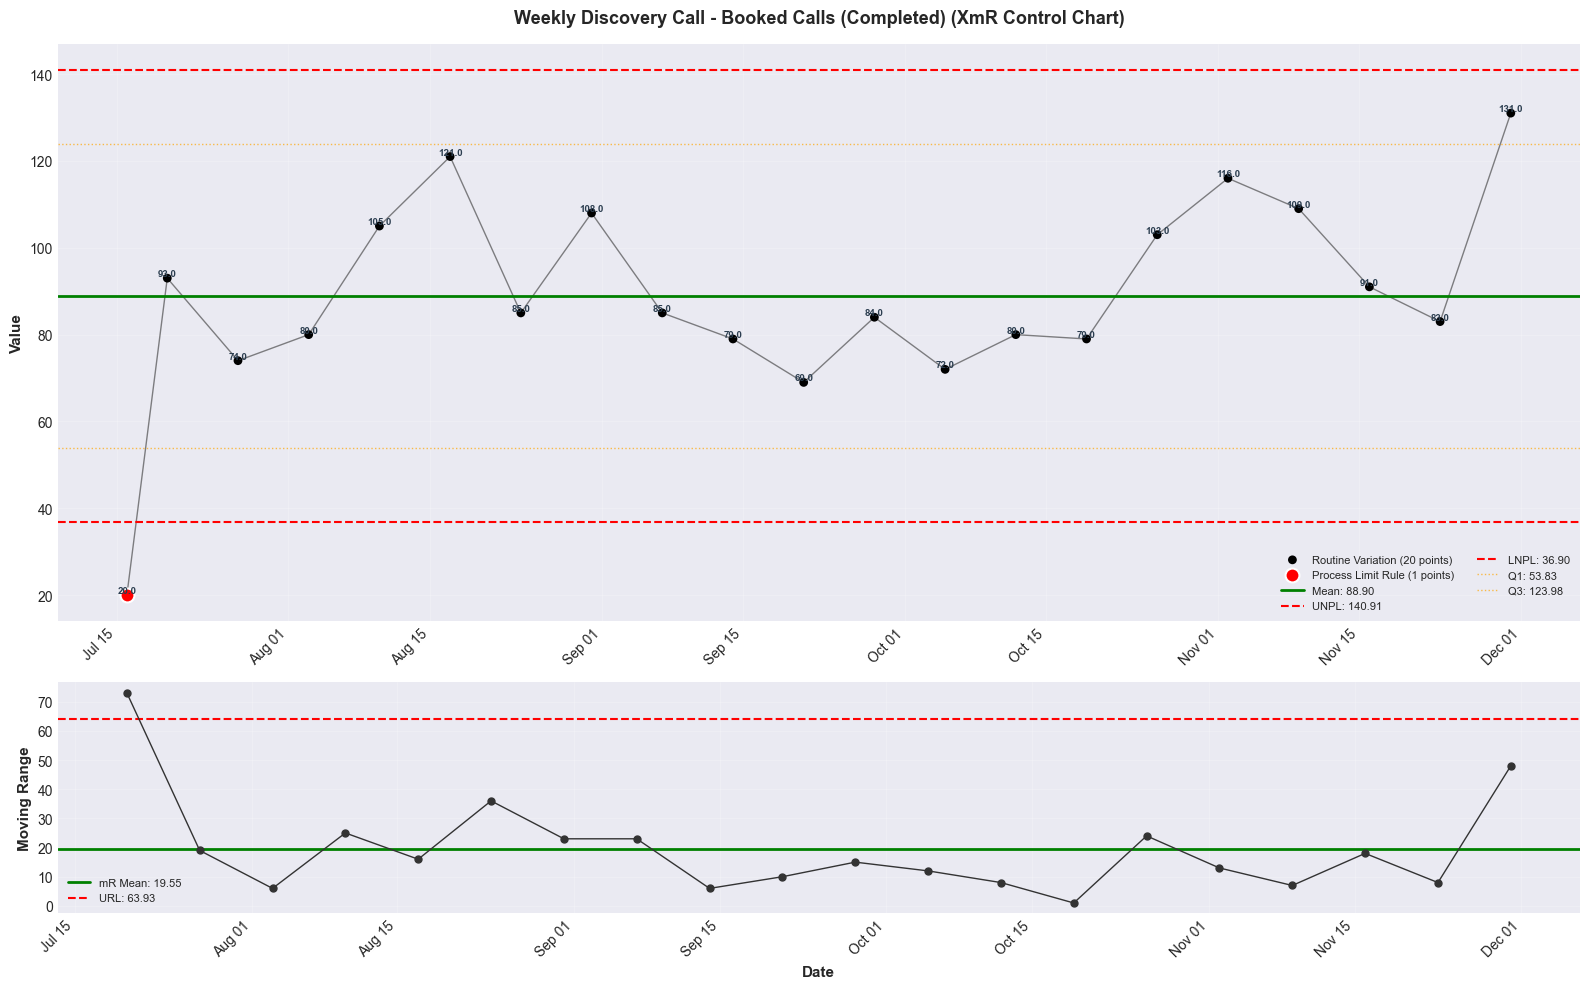

In [29]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY CALL - WEEKLY CHARTS")
print("=" * 70 + "\n")

# Weekly Avg Lead Time (Completed)
plot_xmr_from_csv(
    csv_path='../outputs/discovery_intro/weekly_discovery_call.csv',
    date_col='Date Range',
    value_col='Avg Lead Time (Days)(Completed)',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_discovery_weekly_dir}/weekly_avg_lead_time_completed.png',
    chart_title='Weekly Discovery Call - Avg Lead Time (Days)(Completed) (XmR Control Chart)'
)

# Weekly Booked Calls (Completed)
plot_xmr_from_csv(
    csv_path='../outputs/discovery_intro/weekly_discovery_call.csv',
    date_col='Date Range',
    value_col='Booked Calls (Completed)',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_discovery_weekly_dir}/weekly_booked_calls_completed.png',
    chart_title='Weekly Discovery Call - Booked Calls (Completed) (XmR Control Chart)'
)

### Generate Discovery Call Charts - Monthly


GENERATING DISCOVERY CALL - MONTHLY CHARTS

✓ Loaded 6 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 5 complete months
✓ Target line added: 4.00
✓ Chart saved to: ../visualizations/discovery_call_monthly/monthly_avg_lead_time_completed.png

MONTHLY PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Complete Months Analyzed: 5
Latest Complete Month: November 2025
Latest Month Value: 3.91
Target: 4.00
Gap to Target: -0.09

Month-over-Month Changes:
  Latest MoM Change: +43.22%
  Average MoM Change: 6.25%

Best Month: Nov 2025 (3.91)
Worst Month: Aug 2025 (2.37)

✓ Loaded 6 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 5 complete months
✓ Target line added: 500.00
✓ Chart saved to: ../visualizations/discovery_call_monthly/monthly_booked_calls_c

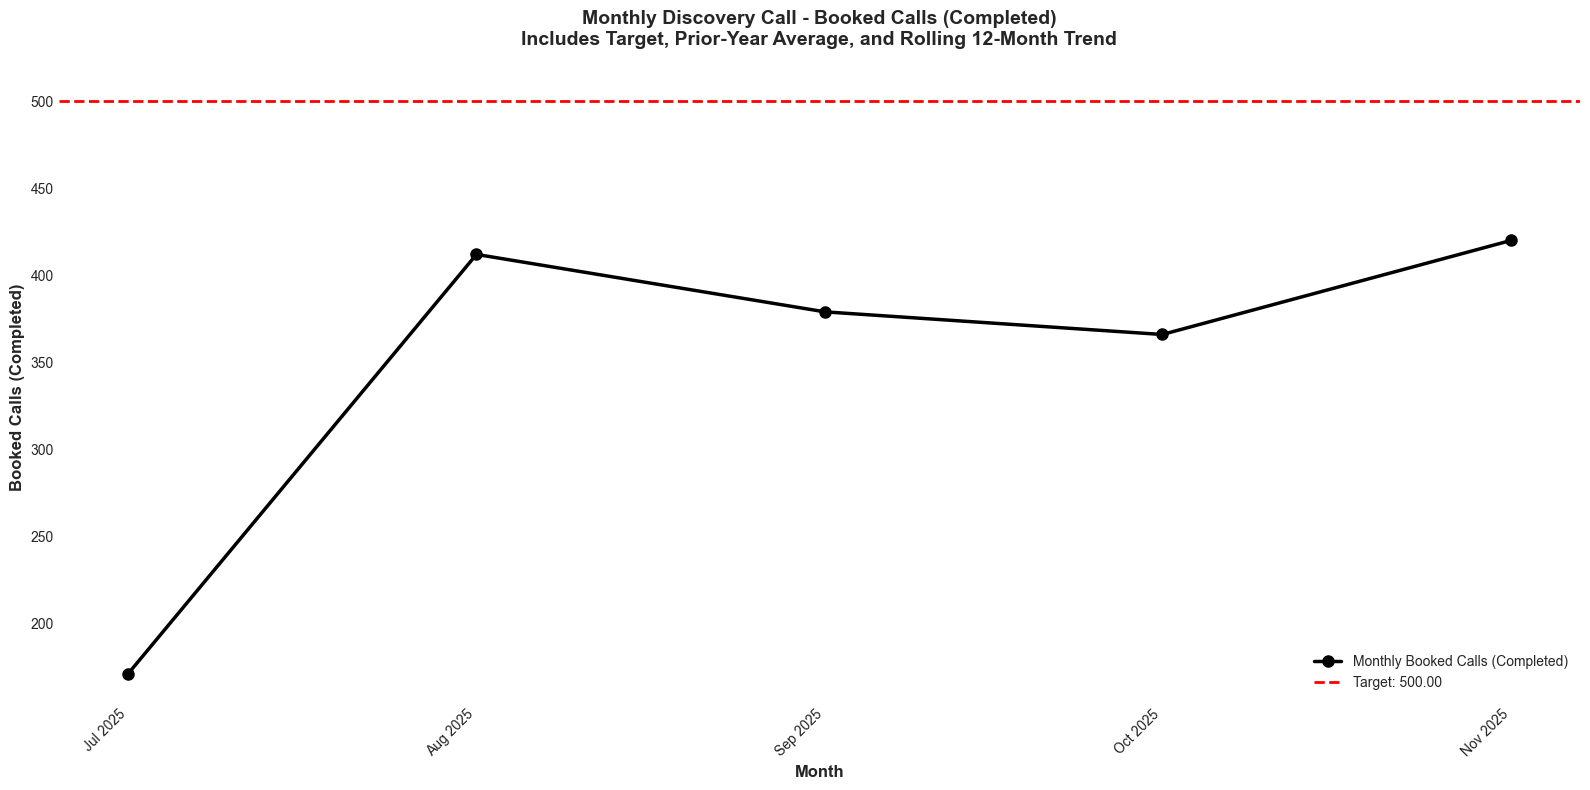

In [30]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY CALL - MONTHLY CHARTS")
print("=" * 70 + "\n")

# Monthly Avg Lead Time (Completed)
create_monthly_chart(
    csv_path='../outputs/discovery_intro/monthly_discovery_call.csv',
    date_col='Month',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=monthly_avg_lead_time_target,
    output_path=f'{viz_discovery_monthly_dir}/monthly_avg_lead_time_completed.png',
    chart_title='Monthly Discovery Call - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)',
    start_date=analysis_start,
    end_date=analysis_end
)

# Monthly Booked Calls (Completed)
create_monthly_chart(
    csv_path='../outputs/discovery_intro/monthly_discovery_call.csv',
    date_col='Month',
    metric_col='Booked Calls (Completed)',
    target_value=monthly_booked_discovery_target,
    output_path=f'{viz_discovery_monthly_dir}/monthly_booked_calls_completed.png',
    chart_title='Monthly Discovery Call - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Discovery Call Charts - Quarterly


GENERATING DISCOVERY CALL - QUARTERLY CHARTS

✓ Loaded 2 quarterly records
✓ Visualizing 2 quarters
✓ Target line added: 3.00
✓ Chart saved to: ../visualizations/discovery_call_quarterly/quarterly_avg_lead_time_completed.png

QUARTERLY PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Quarters Analyzed: 2
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/12/2025
Latest Quarter Value: 3.31
Target: 3.00
Gap to Target: +0.31

Latest QoQ Change: +23.51%

Best Quarter: 2025Q4 (3.31)
Worst Quarter: 2025Q3 (2.68)

✓ Loaded 2 quarterly records
✓ Visualizing 2 quarters
✓ Target line added: 1000.00
✓ Chart saved to: ../visualizations/discovery_call_quarterly/quarterly_booked_calls_completed.png

QUARTERLY PERFORMANCE SUMMARY: Booked Calls (Completed)
Total Quarters Analyzed: 2
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/12/2025
Latest Quarter Value: 989.00
Target: 1000.00
Gap to Target: -11.00

Latest QoQ Change: +2.81%

Best Quarter: 2025Q4 (989.00)
Worst Quarter: 2025Q3 (962.

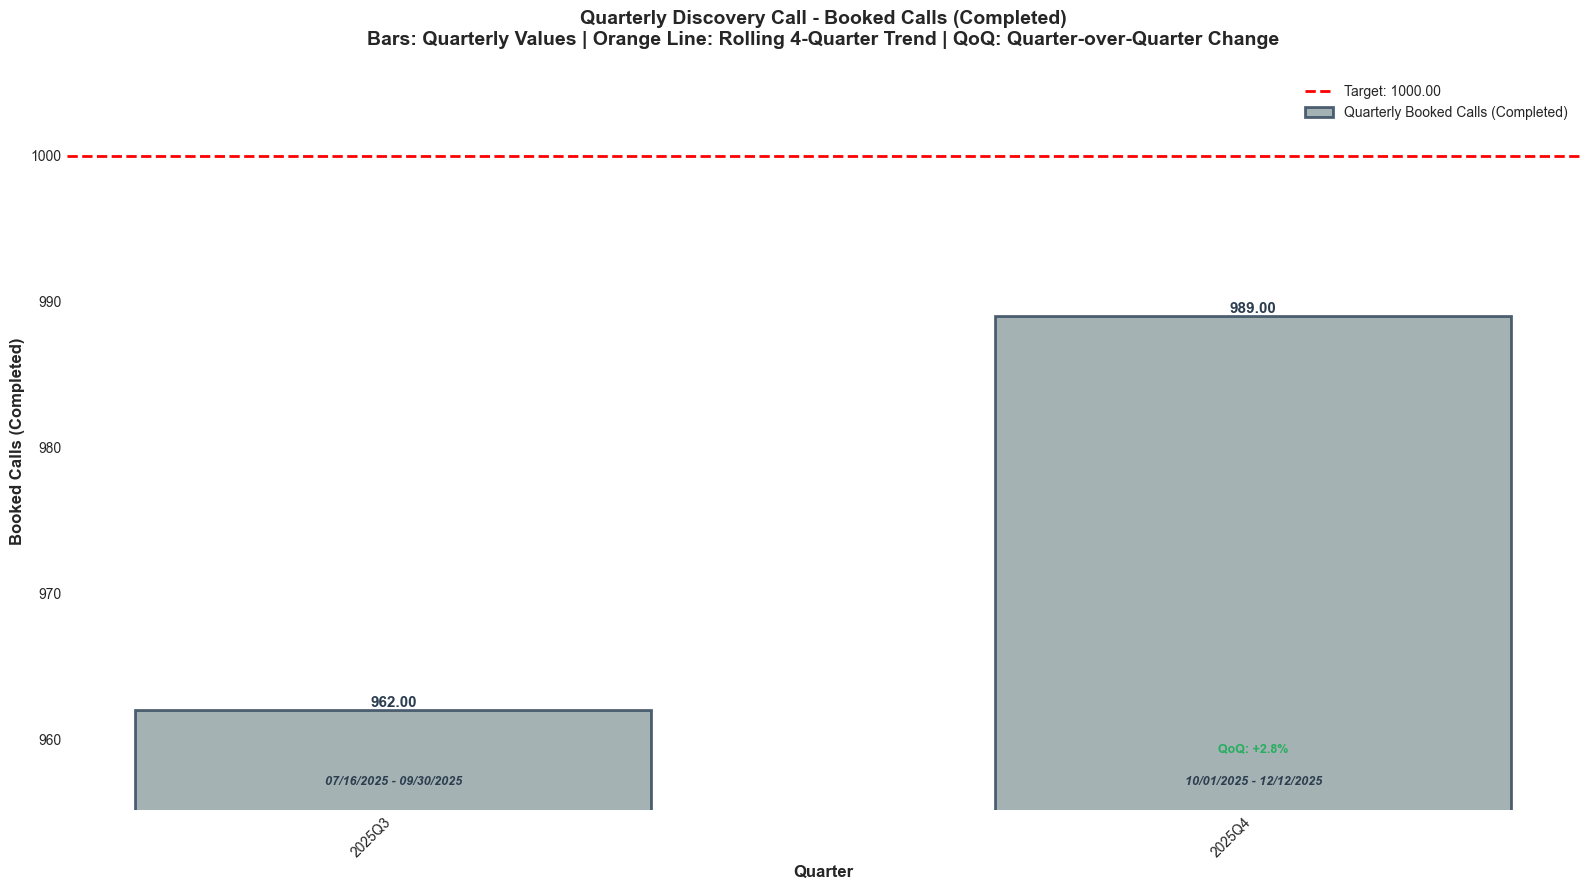

In [31]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY CALL - QUARTERLY CHARTS")
print("=" * 70 + "\n")

# Quarterly Avg Lead Time (Completed)
create_quarterly_chart(
    csv_path='../outputs/discovery_intro/quarterly_discovery_call.csv',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=quarterly_avg_lead_time_target,
    output_path=f'{viz_discovery_quarterly_dir}/quarterly_avg_lead_time_completed.png',
    chart_title='Quarterly Discovery Call - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)'
)

# Quarterly Booked Calls (Completed)
create_quarterly_chart(
    csv_path='../outputs/discovery_intro/quarterly_discovery_call.csv',
    metric_col='Booked Calls (Completed)',
    target_value=quarterly_booked_discovery_target,
    output_path=f'{viz_discovery_quarterly_dir}/quarterly_booked_calls_completed.png',
    chart_title='Quarterly Discovery Call - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)'
)

### Generate Discovery Call Charts - Annual


GENERATING DISCOVERY CALL - ANNUAL CHARTS

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 2500.00
✓ Chart saved to: ../visualizations/discovery_call_annual/annual_avg_lead_time_completed.png

ANNUAL PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 2.99
Date Range: 07/16/2025 - 12/12/2025
Target: 2500.00
Gap to Target: -2497.01

Best Year: 2025 (2.99)
Worst Year: 2025 (2.99)

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 1500.00
✓ Chart saved to: ../visualizations/discovery_call_annual/annual_booked_calls_completed.png

ANNUAL PERFORMANCE SUMMARY: Booked Calls (Completed)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 1951.00
Date Range: 07/16/2025 - 12/12/2025
Target: 1500.00
Gap to Target: +451.00

Best Year: 2025 (1951.00)
Worst Year: 2025 (1951.00)



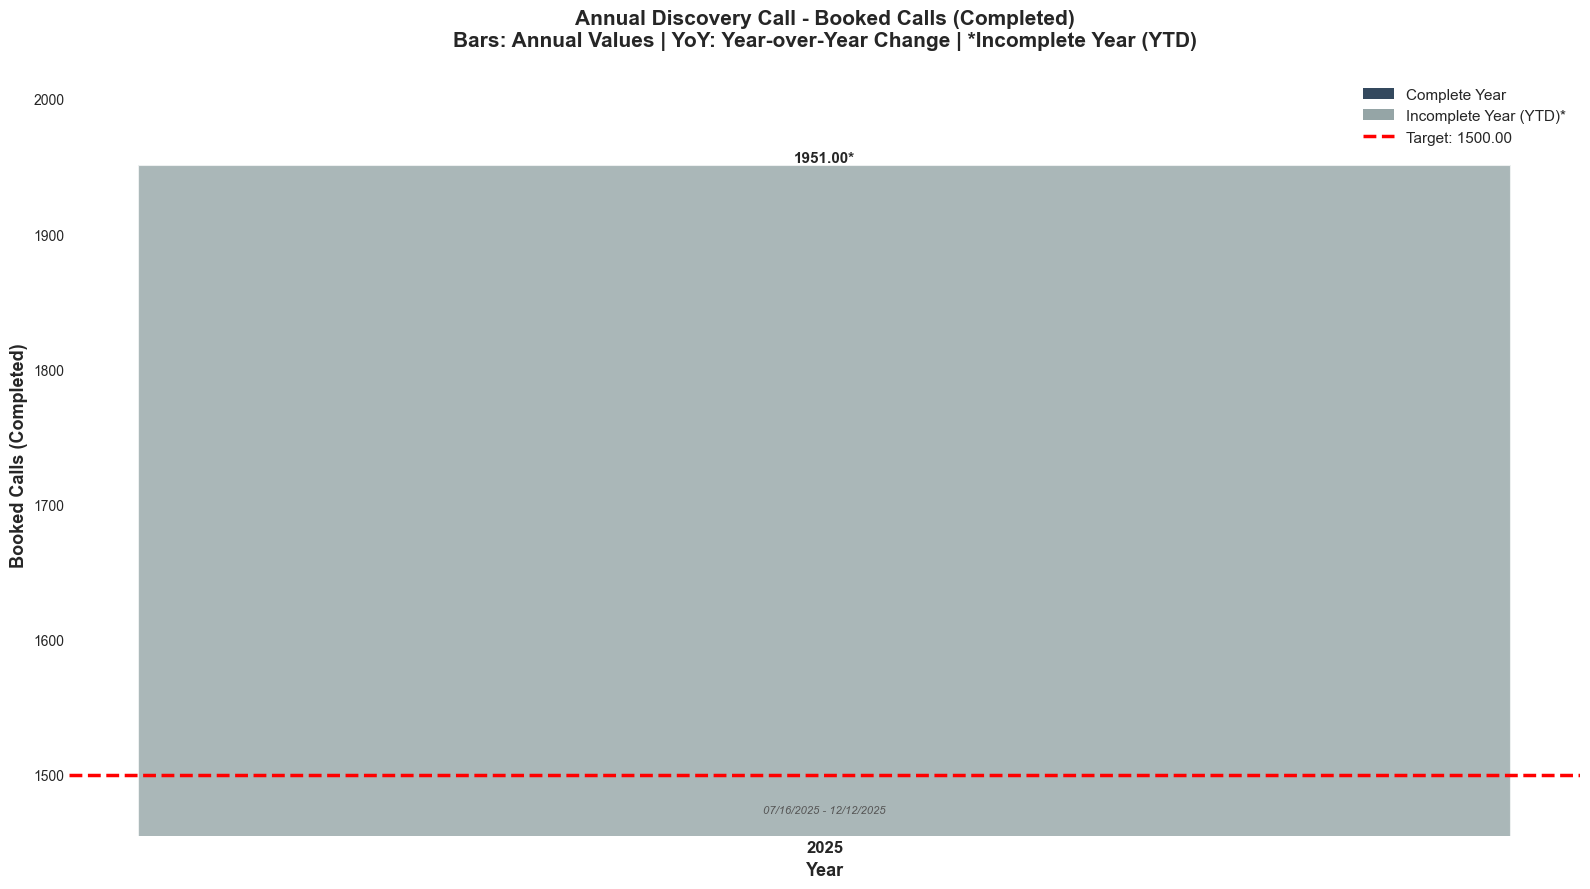

In [32]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY CALL - ANNUAL CHARTS")
print("=" * 70 + "\n")

# Annual Avg Lead Time (Completed)
create_annual_chart(
    csv_path='../outputs/discovery_intro/annual_discovery_call.csv',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=annual_avg_lead_time_target,
    output_path=f'{viz_discovery_annual_dir}/annual_avg_lead_time_completed.png',
    chart_title='Annual Discovery Call - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)'
)

# Annual Booked Calls (Completed)
create_annual_chart(
    csv_path='../outputs/discovery_intro/annual_discovery_call.csv',
    metric_col='Booked Calls (Completed)',
    target_value=annual_booked_discovery_target,
    output_path=f'{viz_discovery_annual_dir}/annual_booked_calls_completed.png',
    chart_title='Annual Discovery Call - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)'
)

###  Generate Intro Call Charts - Weekly


GENERATING INTRO CALL - WEEKLY CHARTS

✓ Loaded 22 rows from weekly_intro_call.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 21 data points
✓ Chart saved to: ../visualizations/intro_call_weekly/weekly_avg_lead_time_completed.png

XmR CHART STATISTICS
Mean: 2.66
UNPL: 3.49
LNPL: 1.83
Q1: 2.10, Q3: 3.22
Moving Range Mean: 0.31
URL (mR): 1.02

Rule Violations Detected:
  Rule 1 (Process Limit): 2 points
  Rule 2 (Quartile): 0 points
  Rule 3 (Runs of 8): 13 points
  Routine Variation: 6 points

✓ Loaded 22 rows from weekly_intro_call.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 21 data points
✓ Chart saved to: ../visualizations/intro_call_weekly/weekly_booked_calls_completed.png

XmR CHART STATISTICS
Mean: 23.62
UNPL: 37.85
LNPL: 9.39
Q1: 14.02, Q3: 33.22
Moving Range Mean: 5.35
URL (mR): 17.49

Rule Violations Detected:
  Rule 1 (Process Limit): 4 points
  Rule 2 (Quartile): 

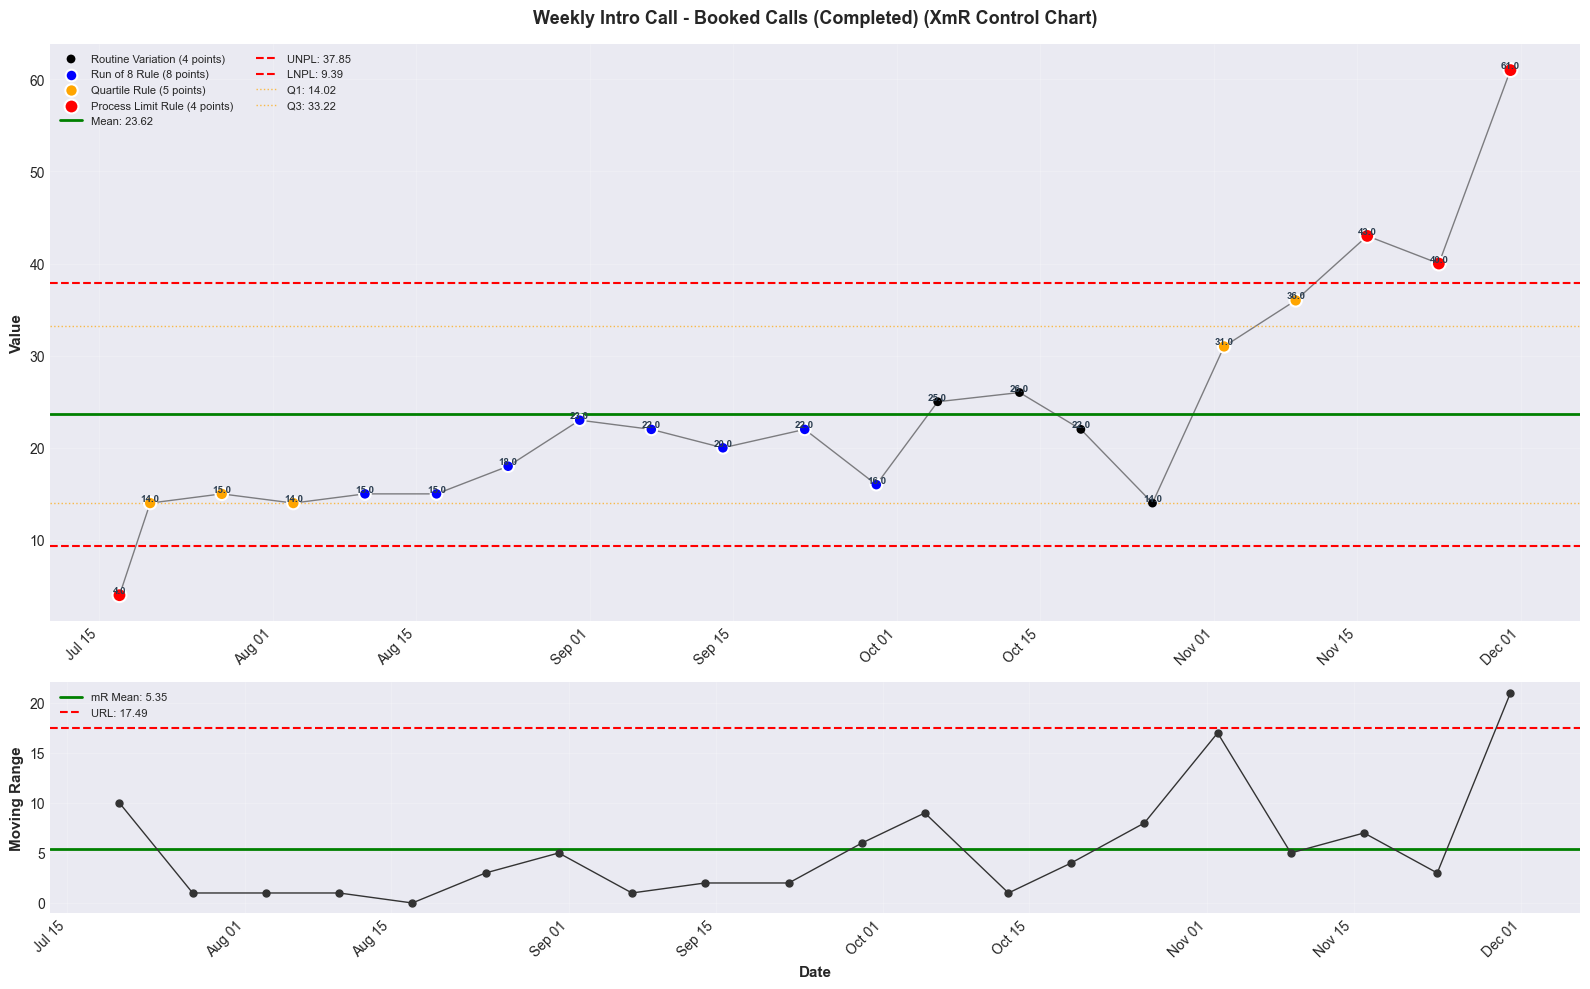

In [33]:
print("\n" + "=" * 70)
print("GENERATING INTRO CALL - WEEKLY CHARTS")
print("=" * 70 + "\n")

# Weekly Avg Lead Time (Completed)
plot_xmr_from_csv(
    csv_path='../outputs/discovery_intro/weekly_intro_call.csv',
    date_col='Date Range',
    value_col='Avg Lead Time (Days)(Completed)',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_intro_weekly_dir}/weekly_avg_lead_time_completed.png',
    chart_title='Weekly Intro Call - Avg Lead Time (Days)(Completed) (XmR Control Chart)'
)

# Weekly Booked Calls (Completed)
plot_xmr_from_csv(
    csv_path='../outputs/discovery_intro/weekly_intro_call.csv',
    date_col='Date Range',
    value_col='Booked Calls (Completed)',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_intro_weekly_dir}/weekly_booked_calls_completed.png',
    chart_title='Weekly Intro Call - Booked Calls (Completed) (XmR Control Chart)'
)

### Generate Intro Call Charts - Monthly


GENERATING INTRO CALL - MONTHLY CHARTS

✓ Loaded 6 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 5 complete months
✓ Target line added: 4.00
✓ Chart saved to: ../visualizations/intro_call_monthly/monthly_avg_lead_time_completed.png

MONTHLY PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Complete Months Analyzed: 5
Latest Complete Month: November 2025
Latest Month Value: 3.26
Target: 4.00
Gap to Target: -0.74

Month-over-Month Changes:
  Latest MoM Change: +41.74%
  Average MoM Change: 4.92%

Best Month: Nov 2025 (3.26)
Worst Month: Sep 2025 (2.24)

✓ Loaded 6 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 5 complete months
✓ Target line added: 120.00
✓ Chart saved to: ../visualizations/intro_call_monthly/monthly_booked_calls_completed.png

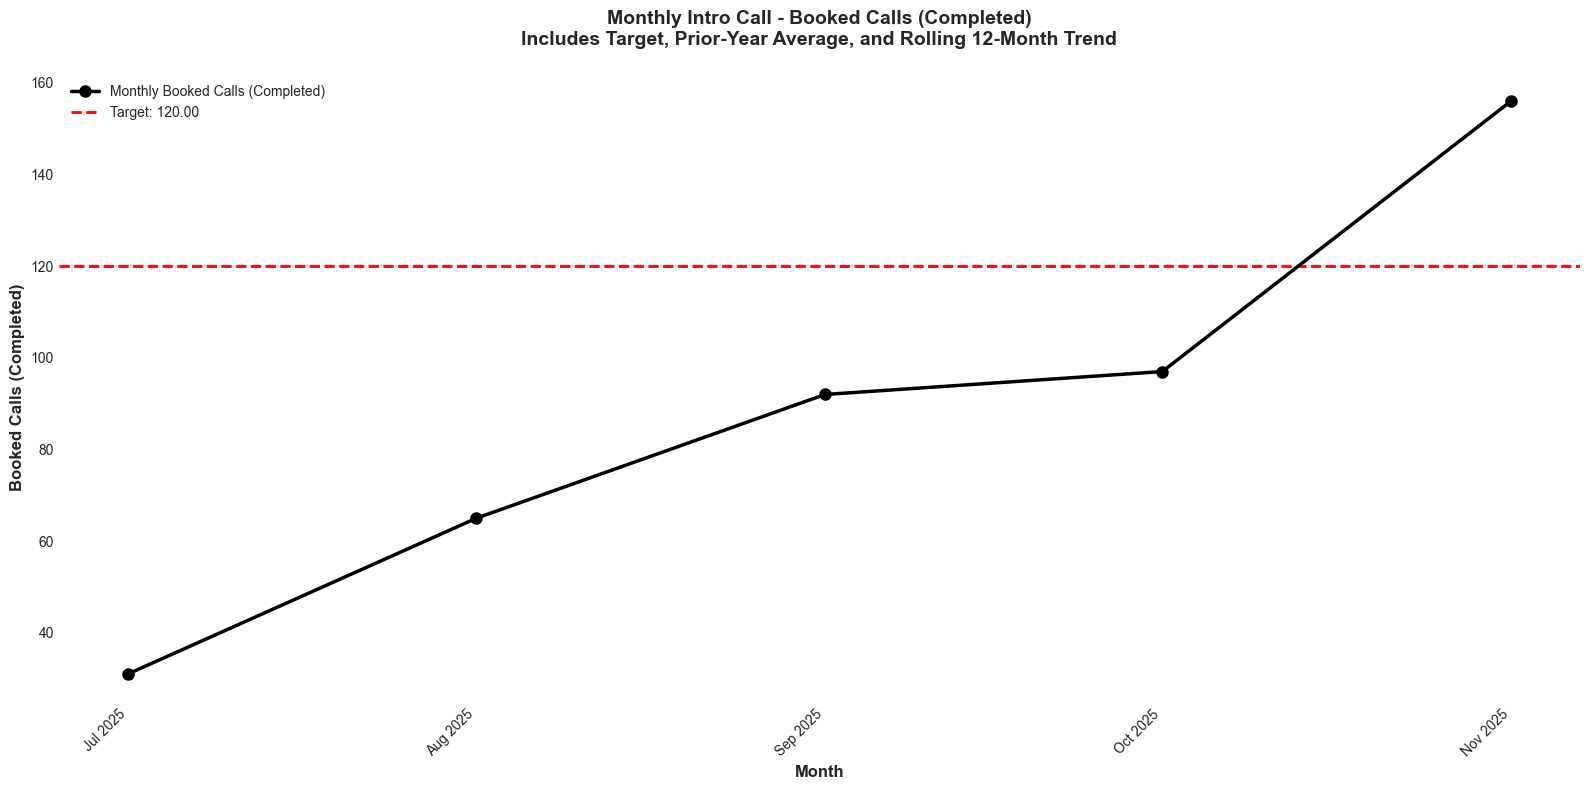

In [34]:
print("\n" + "=" * 70)
print("GENERATING INTRO CALL - MONTHLY CHARTS")
print("=" * 70 + "\n")

# Monthly Avg Lead Time (Completed)
create_monthly_chart(
    csv_path='../outputs/discovery_intro/monthly_intro_call.csv',
    date_col='Month',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=monthly_avg_lead_time_target,
    output_path=f'{viz_intro_monthly_dir}/monthly_avg_lead_time_completed.png',
    chart_title='Monthly Intro Call - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)',
    start_date=analysis_start,
    end_date=analysis_end
)

# Monthly Booked Calls (Completed)
create_monthly_chart(
    csv_path='../outputs/discovery_intro/monthly_intro_call.csv',
    date_col='Month',
    metric_col='Booked Calls (Completed)',
    target_value=monthly_booked_intro_target,
    output_path=f'{viz_intro_monthly_dir}/monthly_booked_calls_completed.png',
    chart_title='Monthly Intro Call - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Intro Call Charts - Quarterly


GENERATING INTRO CALL - QUARTERLY CHARTS

✓ Loaded 2 quarterly records
✓ Visualizing 2 quarters
✓ Target line added: 3.00
✓ Chart saved to: ../visualizations/intro_call_quarterly/quarterly_avg_lead_time_completed.png

QUARTERLY PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Quarters Analyzed: 2
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/12/2025
Latest Quarter Value: 3.10
Target: 3.00
Gap to Target: +0.10

Latest QoQ Change: +28.63%

Best Quarter: 2025Q4 (3.10)
Worst Quarter: 2025Q3 (2.41)

✓ Loaded 2 quarterly records
✓ Visualizing 2 quarters
✓ Target line added: 350.00
✓ Chart saved to: ../visualizations/intro_call_quarterly/quarterly_booked_calls_completed.png

QUARTERLY PERFORMANCE SUMMARY: Booked Calls (Completed)
Total Quarters Analyzed: 2
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/12/2025
Latest Quarter Value: 392.00
Target: 350.00
Gap to Target: +42.00

Latest QoQ Change: +108.51%

Best Quarter: 2025Q4 (392.00)
Worst Quarter: 2025Q3 (188.00)



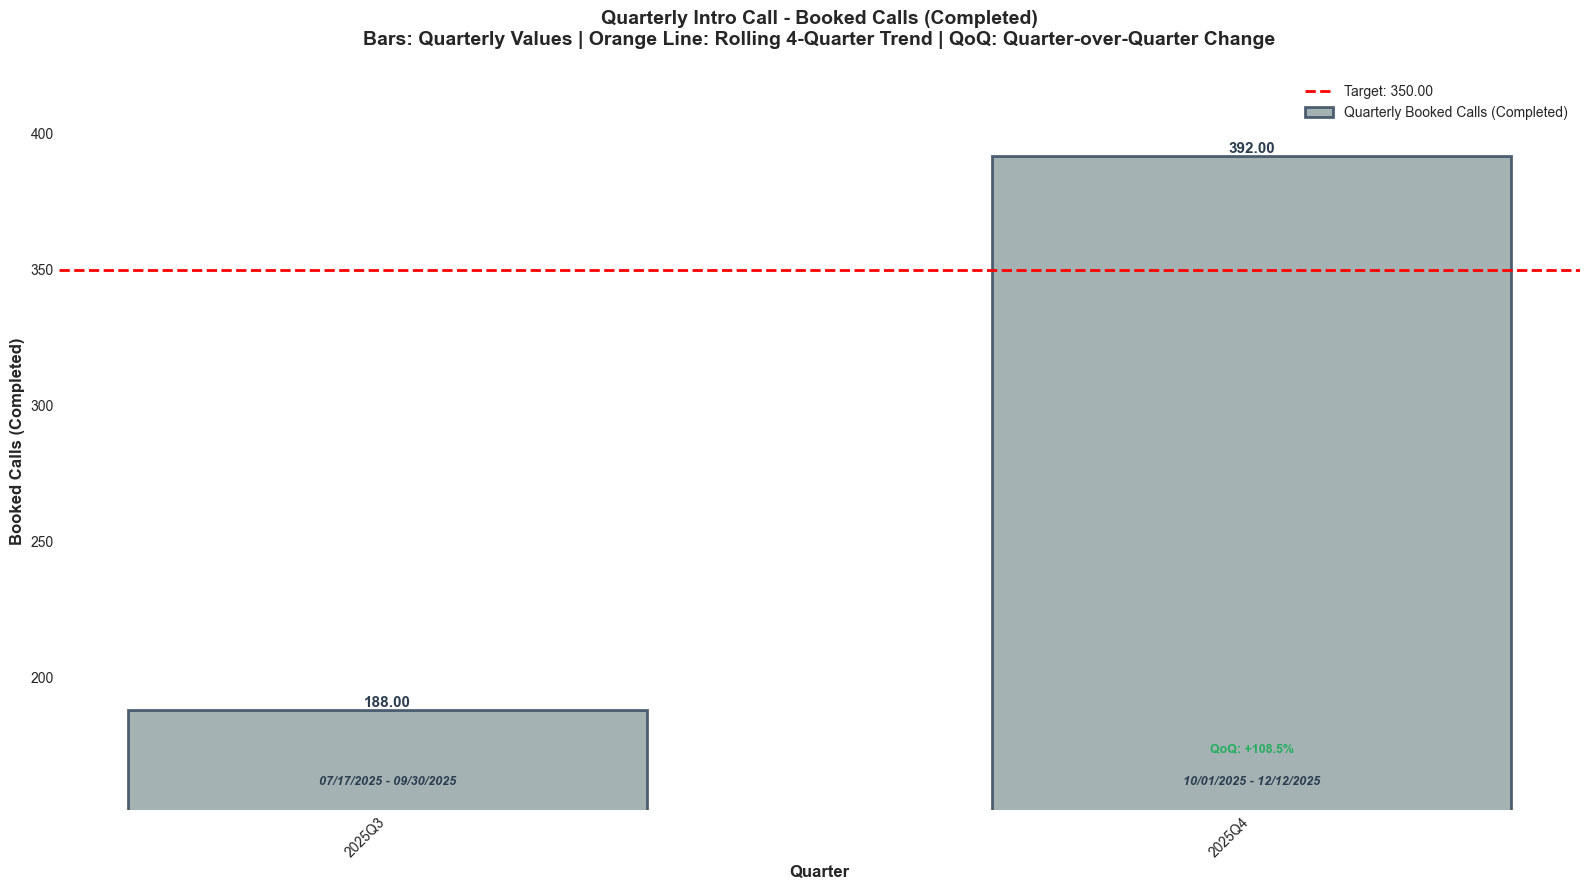

In [35]:
print("\n" + "=" * 70)
print("GENERATING INTRO CALL - QUARTERLY CHARTS")
print("=" * 70 + "\n")

# Quarterly Avg Lead Time (Completed)
create_quarterly_chart(
    csv_path='../outputs/discovery_intro/quarterly_intro_call.csv',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=quarterly_avg_lead_time_target,
    output_path=f'{viz_intro_quarterly_dir}/quarterly_avg_lead_time_completed.png',
    chart_title='Quarterly Intro Call - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)'
)

# Quarterly Booked Calls (Completed)
create_quarterly_chart(
    csv_path='../outputs/discovery_intro/quarterly_intro_call.csv',
    metric_col='Booked Calls (Completed)',
    target_value=quarterly_booked_intro_target,
    output_path=f'{viz_intro_quarterly_dir}/quarterly_booked_calls_completed.png',
    chart_title='Quarterly Intro Call - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)'
)

### Generate Intro Call Charts - Annual


GENERATING INTRO CALL - ANNUAL CHARTS

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 2500.00
✓ Chart saved to: ../visualizations/intro_call_annual/annual_avg_lead_time_completed.png

ANNUAL PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 2.75
Date Range: 07/17/2025 - 12/12/2025
Target: 2500.00
Gap to Target: -2497.25

Best Year: 2025 (2.75)
Worst Year: 2025 (2.75)

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 500.00
✓ Chart saved to: ../visualizations/intro_call_annual/annual_booked_calls_completed.png

ANNUAL PERFORMANCE SUMMARY: Booked Calls (Completed)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 580.00
Date Range: 07/17/2025 - 12/12/2025
Target: 500.00
Gap to Target: +80.00

Best Year: 2025 (580.00)
Worst Year: 2025 (580.00)



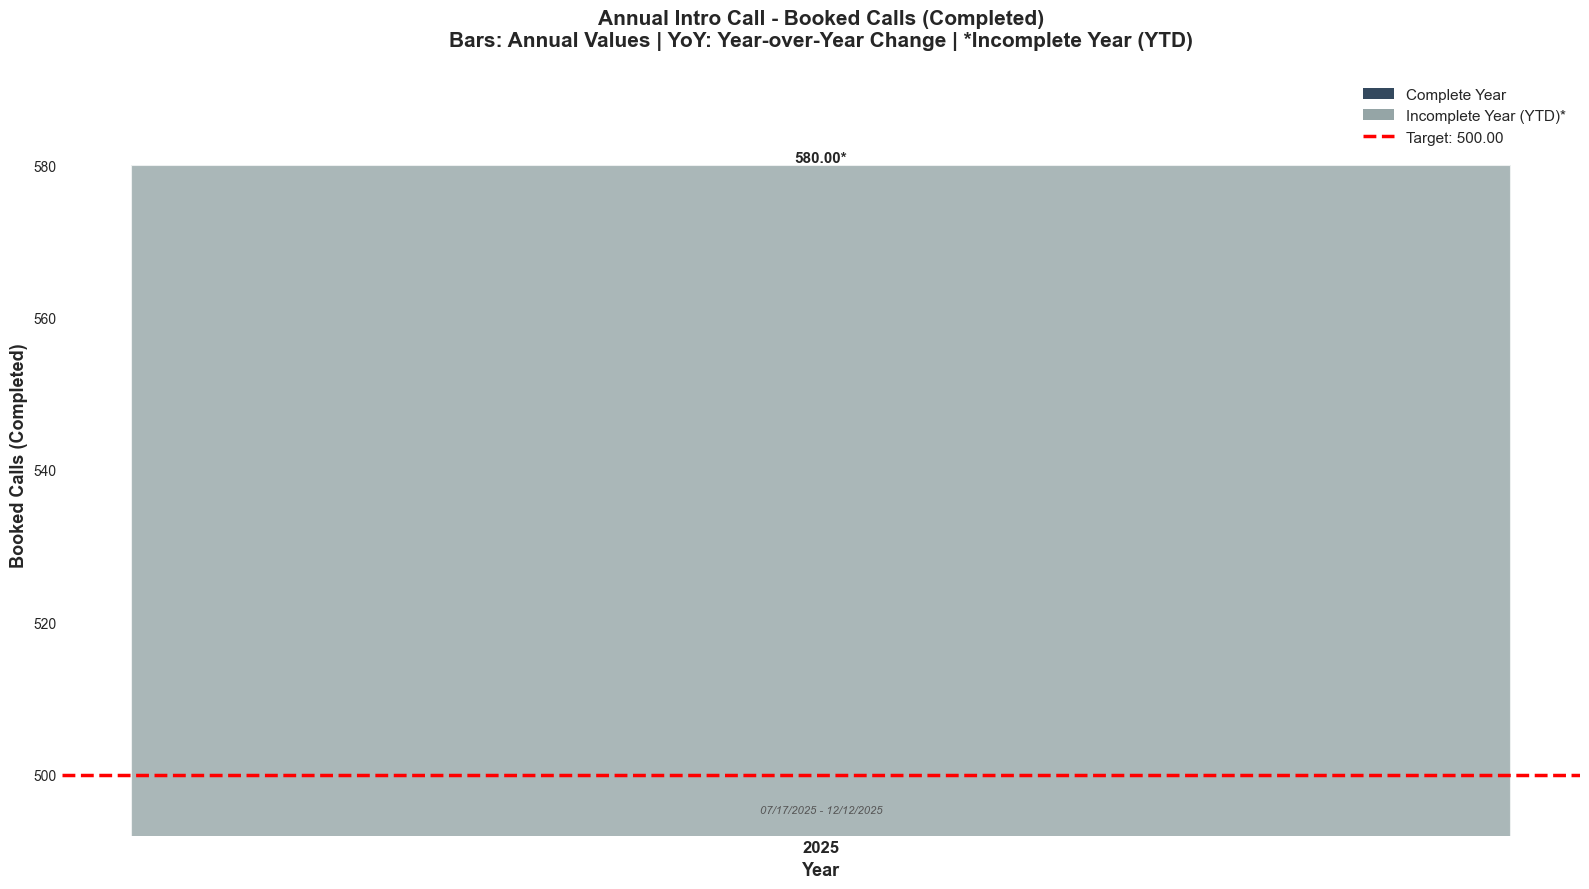

In [36]:
print("\n" + "=" * 70)
print("GENERATING INTRO CALL - ANNUAL CHARTS")
print("=" * 70 + "\n")

# Annual Avg Lead Time (Completed)
create_annual_chart(
    csv_path='../outputs/discovery_intro/annual_intro_call.csv',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=annual_avg_lead_time_target,
    output_path=f'{viz_intro_annual_dir}/annual_avg_lead_time_completed.png',
    chart_title='Annual Intro Call - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)'
)

# Annual Booked Calls (Completed)
create_annual_chart(
    csv_path='../outputs/discovery_intro/annual_intro_call.csv',
    metric_col='Booked Calls (Completed)',
    target_value=annual_booked_intro_target,
    output_path=f'{viz_intro_annual_dir}/annual_booked_calls_completed.png',
    chart_title='Annual Intro Call - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)'
)

### Generate Blended Charts - Weekly


GENERATING DISCOVERY & INTRO CALL (BLENDED) - WEEKLY CHARTS

✓ Loaded 22 rows from weekly_discovery_intro_blended.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 21 data points
✓ Chart saved to: ../visualizations/discovery_intro_blended_weekly/weekly_avg_lead_time_completed.png

XmR CHART STATISTICS
Mean: 2.96
UNPL: 3.80
LNPL: 2.12
Q1: 2.39, Q3: 3.53
Moving Range Mean: 0.32
URL (mR): 1.03

Rule Violations Detected:
  Rule 1 (Process Limit): 2 points
  Rule 2 (Quartile): 8 points
  Rule 3 (Runs of 8): 12 points
  Routine Variation: 4 points

✓ Loaded 22 rows from weekly_discovery_intro_blended.csv
✓ Filtered to dates >= 2025-01-01 00:00:00
✓ Filtered to dates <= 2025-12-06 00:00:00
✓ Analyzing 21 data points
✓ Chart saved to: ../visualizations/discovery_intro_blended_weekly/weekly_booked_calls_completed.png

XmR CHART STATISTICS
Mean: 112.52
UNPL: 167.59
LNPL: 57.46
Q1: 75.38, Q3: 149.66
Moving Range Mean: 20.70
URL (mR): 67.69

Rul

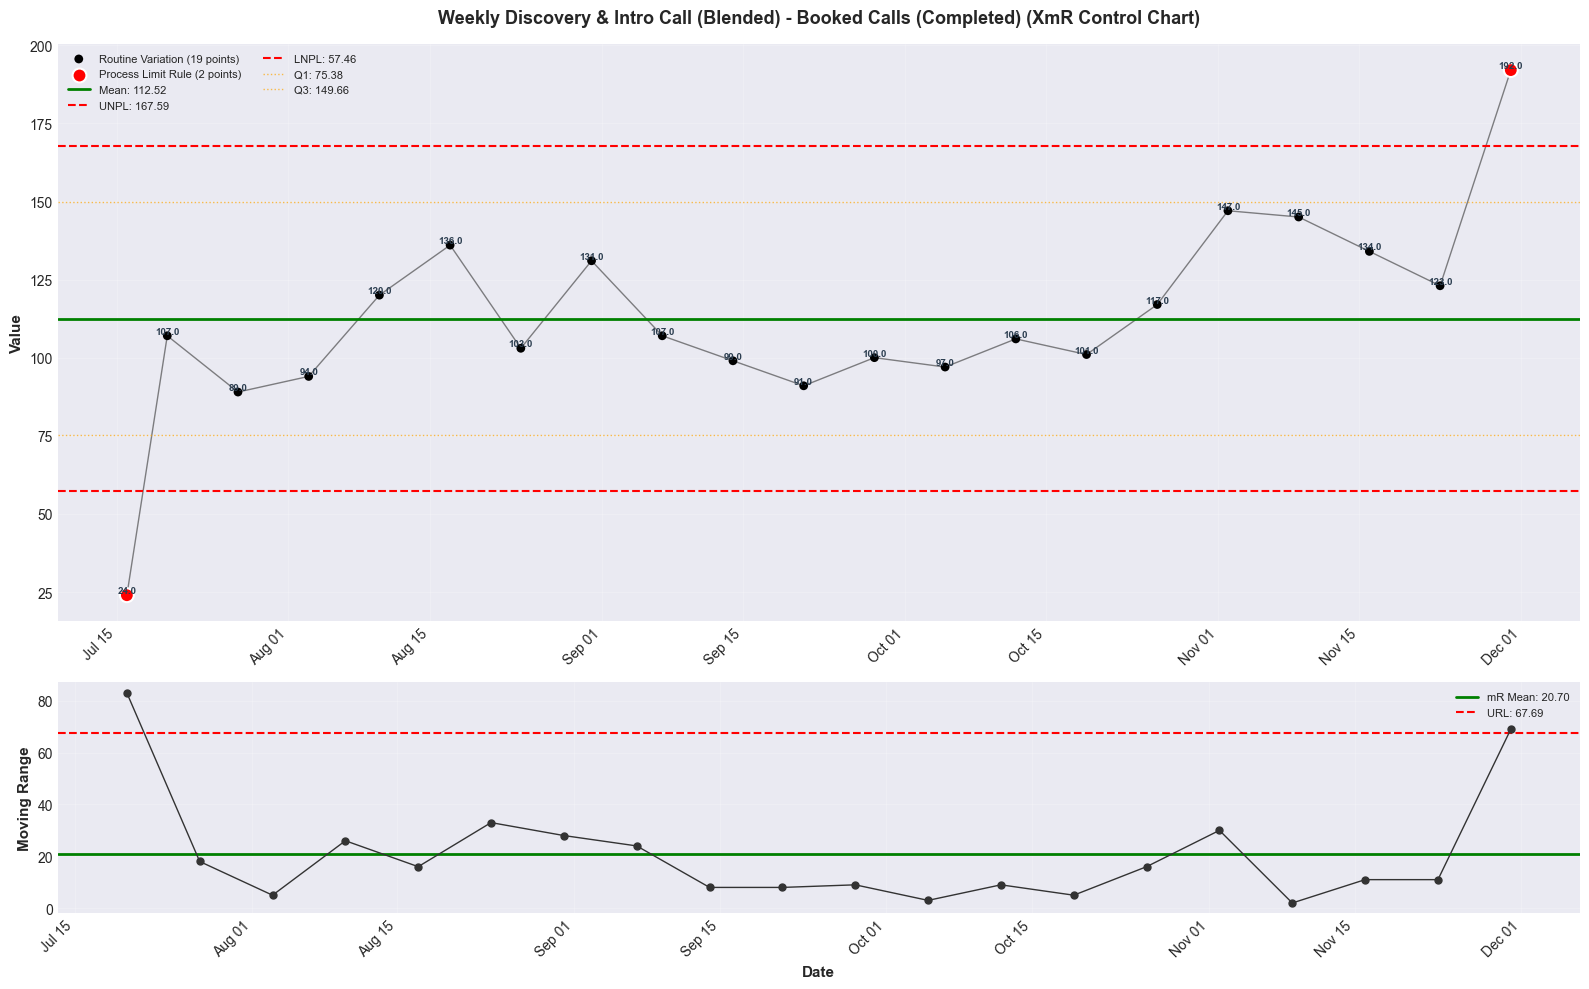

In [37]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY & INTRO CALL (BLENDED) - WEEKLY CHARTS")
print("=" * 70 + "\n")

# Weekly Avg Lead Time (Completed)
plot_xmr_from_csv(
    csv_path='../outputs/discovery_intro/weekly_discovery_intro_blended.csv',
    date_col='Date Range',
    value_col='Avg Lead Time (Days)(Completed)',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_blended_weekly_dir}/weekly_avg_lead_time_completed.png',
    chart_title='Weekly Discovery & Intro Call (Blended) - Avg Lead Time (Days)(Completed) (XmR Control Chart)'
)

# Weekly Booked Calls (Completed)
plot_xmr_from_csv(
    csv_path='../outputs/discovery_intro/weekly_discovery_intro_blended.csv',
    date_col='Date Range',
    value_col='Booked Calls (Completed)',
    start_date=analysis_start,
    end_date=analysis_end,
    output_path=f'{viz_blended_weekly_dir}/weekly_booked_calls_completed.png',
    chart_title='Weekly Discovery & Intro Call (Blended) - Booked Calls (Completed) (XmR Control Chart)'
)

### Generate Blended Charts - Monthly


GENERATING DISCOVERY & INTRO CALL (BLENDED) - MONTHLY CHARTS

✓ Loaded 6 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 5 complete months
✓ Target line added: 4.00
✓ Chart saved to: ../visualizations/discovery_intro_blended_monthly/monthly_avg_lead_time_completed.png

MONTHLY PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Complete Months Analyzed: 5
Latest Complete Month: November 2025
Latest Month Value: 3.77
Target: 4.00
Gap to Target: -0.23

Month-over-Month Changes:
  Latest MoM Change: +41.20%
  Average MoM Change: 5.57%

Best Month: Nov 2025 (3.77)
Worst Month: Aug 2025 (2.36)

✓ Loaded 6 monthly records
✓ Filtered to dates >= 2025-01-01
✓ Filtered to dates <= 2025-12-06
⚠️ Excluded 1 records from incomplete current month (December 2025)
✓ Visualizing 5 complete months
✓ Target line added: 620.00
✓ Chart saved to: ../visualizations/discovery_intro_bl

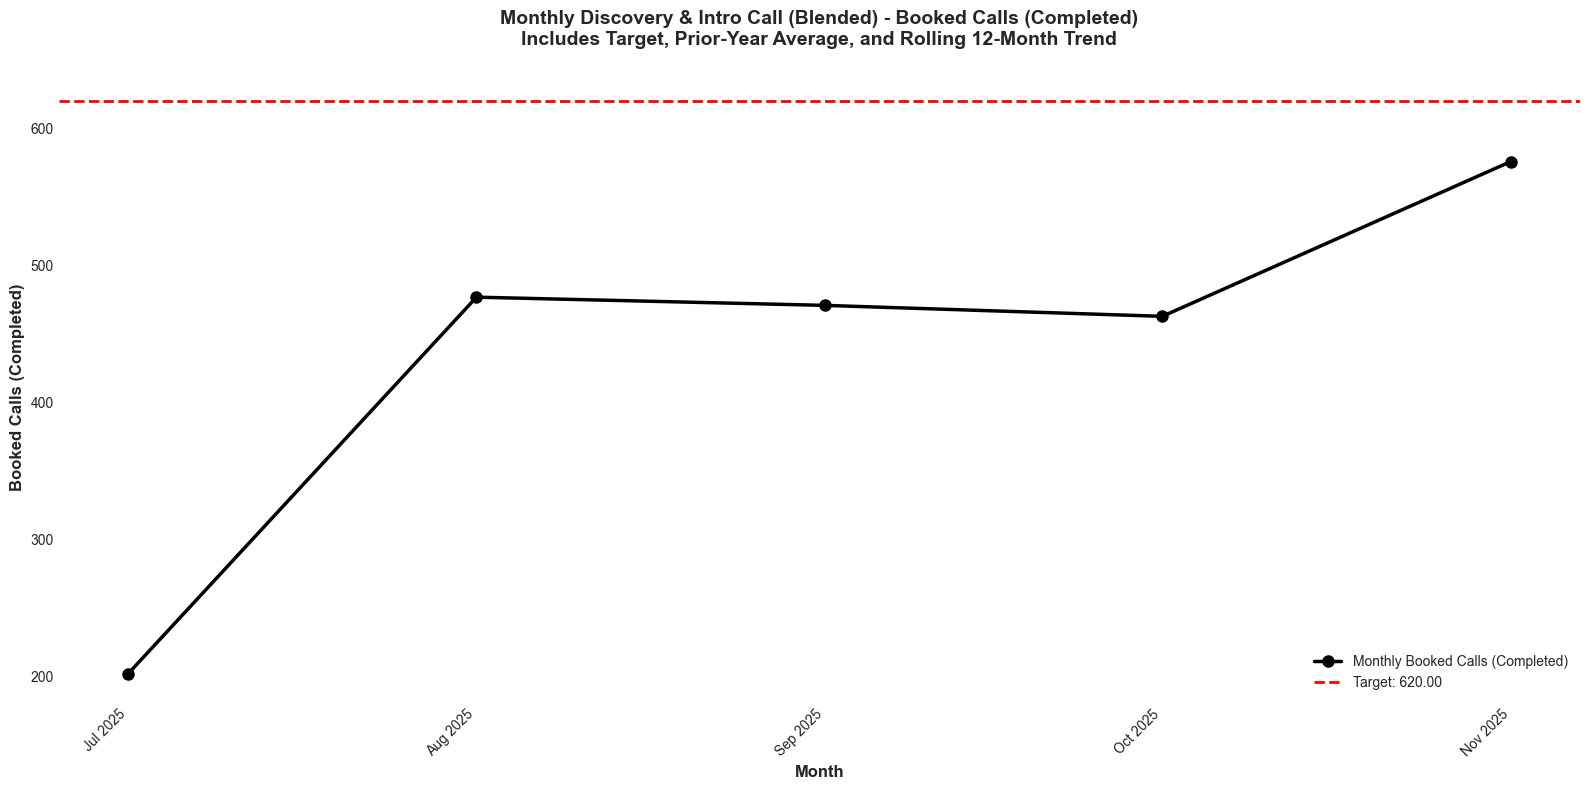

In [38]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY & INTRO CALL (BLENDED) - MONTHLY CHARTS")
print("=" * 70 + "\n")

# Monthly Avg Lead Time (Completed)
create_monthly_chart(
    csv_path='../outputs/discovery_intro/monthly_discovery_intro_blended.csv',
    date_col='Month',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=monthly_avg_lead_time_target,
    output_path=f'{viz_blended_monthly_dir}/monthly_avg_lead_time_completed.png',
    chart_title='Monthly Discovery & Intro Call (Blended) - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)',
    start_date=analysis_start,
    end_date=analysis_end
)

# Monthly Booked Calls (Completed) - We'll use the sum of Discovery + Intro targets
monthly_blended_target = None
if monthly_booked_discovery_target is not None and monthly_booked_intro_target is not None:
    monthly_blended_target = monthly_booked_discovery_target + monthly_booked_intro_target

create_monthly_chart(
    csv_path='../outputs/discovery_intro/monthly_discovery_intro_blended.csv',
    date_col='Month',
    metric_col='Booked Calls (Completed)',
    target_value=monthly_blended_target,
    output_path=f'{viz_blended_monthly_dir}/monthly_booked_calls_completed.png',
    chart_title='Monthly Discovery & Intro Call (Blended) - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)',
    start_date=analysis_start,
    end_date=analysis_end
)

### Generate Blended Charts - Quarterly


GENERATING DISCOVERY & INTRO CALL (BLENDED) - QUARTERLY CHARTS

✓ Loaded 2 quarterly records
✓ Visualizing 2 quarters
✓ Target line added: 3.00
✓ Chart saved to: ../visualizations/discovery_intro_blended_quarterly/quarterly_avg_lead_time_completed.png

QUARTERLY PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Quarters Analyzed: 2
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/12/2025
Latest Quarter Value: 3.32
Target: 3.00
Gap to Target: +0.32

Latest QoQ Change: +23.88%

Best Quarter: 2025Q4 (3.32)
Worst Quarter: 2025Q3 (2.68)

✓ Loaded 2 quarterly records
✓ Visualizing 2 quarters
✓ Target line added: 1350.00
✓ Chart saved to: ../visualizations/discovery_intro_blended_quarterly/quarterly_booked_calls_completed.png

QUARTERLY PERFORMANCE SUMMARY: Booked Calls (Completed)
Total Quarters Analyzed: 2
Latest Quarter: 2025Q4
Date Range: 10/01/2025 - 12/12/2025
Latest Quarter Value: 1381.00
Target: 1350.00
Gap to Target: +31.00

Latest QoQ Change: +20.09%

Best Quarter: 2025Q

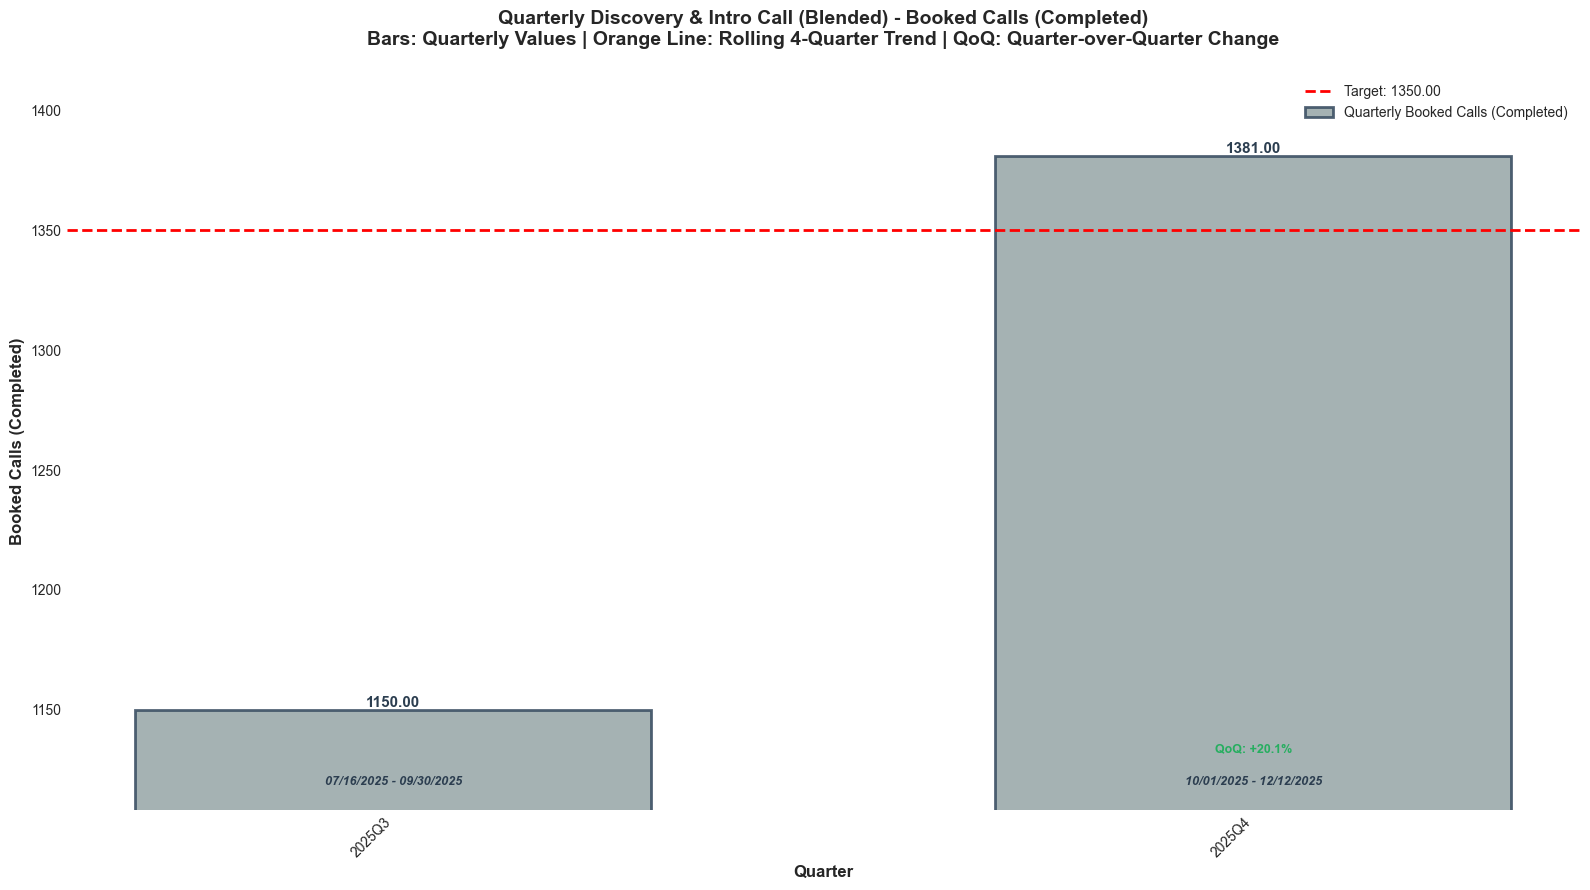

In [39]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY & INTRO CALL (BLENDED) - QUARTERLY CHARTS")
print("=" * 70 + "\n")

# Quarterly Avg Lead Time (Completed)
create_quarterly_chart(
    csv_path='../outputs/discovery_intro/quarterly_discovery_intro_blended.csv',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=quarterly_avg_lead_time_target,
    output_path=f'{viz_blended_quarterly_dir}/quarterly_avg_lead_time_completed.png',
    chart_title='Quarterly Discovery & Intro Call (Blended) - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)'
)

# Quarterly Booked Calls (Completed)
quarterly_blended_target = None
if quarterly_booked_discovery_target is not None and quarterly_booked_intro_target is not None:
    quarterly_blended_target = quarterly_booked_discovery_target + quarterly_booked_intro_target

create_quarterly_chart(
    csv_path='../outputs/discovery_intro/quarterly_discovery_intro_blended.csv',
    metric_col='Booked Calls (Completed)',
    target_value=quarterly_blended_target,
    output_path=f'{viz_blended_quarterly_dir}/quarterly_booked_calls_completed.png',
    chart_title='Quarterly Discovery & Intro Call (Blended) - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)'
)

### Generate Blended Charts - Annual


GENERATING DISCOVERY & INTRO CALL (BLENDED) - ANNUAL CHARTS

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 2500.00
✓ Chart saved to: ../visualizations/discovery_intro_blended_annual/annual_avg_lead_time_completed.png

ANNUAL PERFORMANCE SUMMARY: Avg Lead Time (Days)(Completed)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 2.99
Date Range: 07/16/2025 - 12/12/2025
Target: 2500.00
Gap to Target: -2497.01

Best Year: 2025 (2.99)
Worst Year: 2025 (2.99)

✓ Loaded 1 annual records
✓ Visualizing 1 years
✓ Target line added: 2000.00
✓ Chart saved to: ../visualizations/discovery_intro_blended_annual/annual_booked_calls_completed.png

ANNUAL PERFORMANCE SUMMARY: Booked Calls (Completed)
Total Years: 1
Years: 2025 to 2025
Incomplete Years (YTD): 2025

Latest Year (2025) Value: 2531.00
Date Range: 07/16/2025 - 12/12/2025
Target: 2000.00
Gap to Target: +531.00

Best Year: 2025 (2531.00)
Worst Year: 2025 (2531.00)



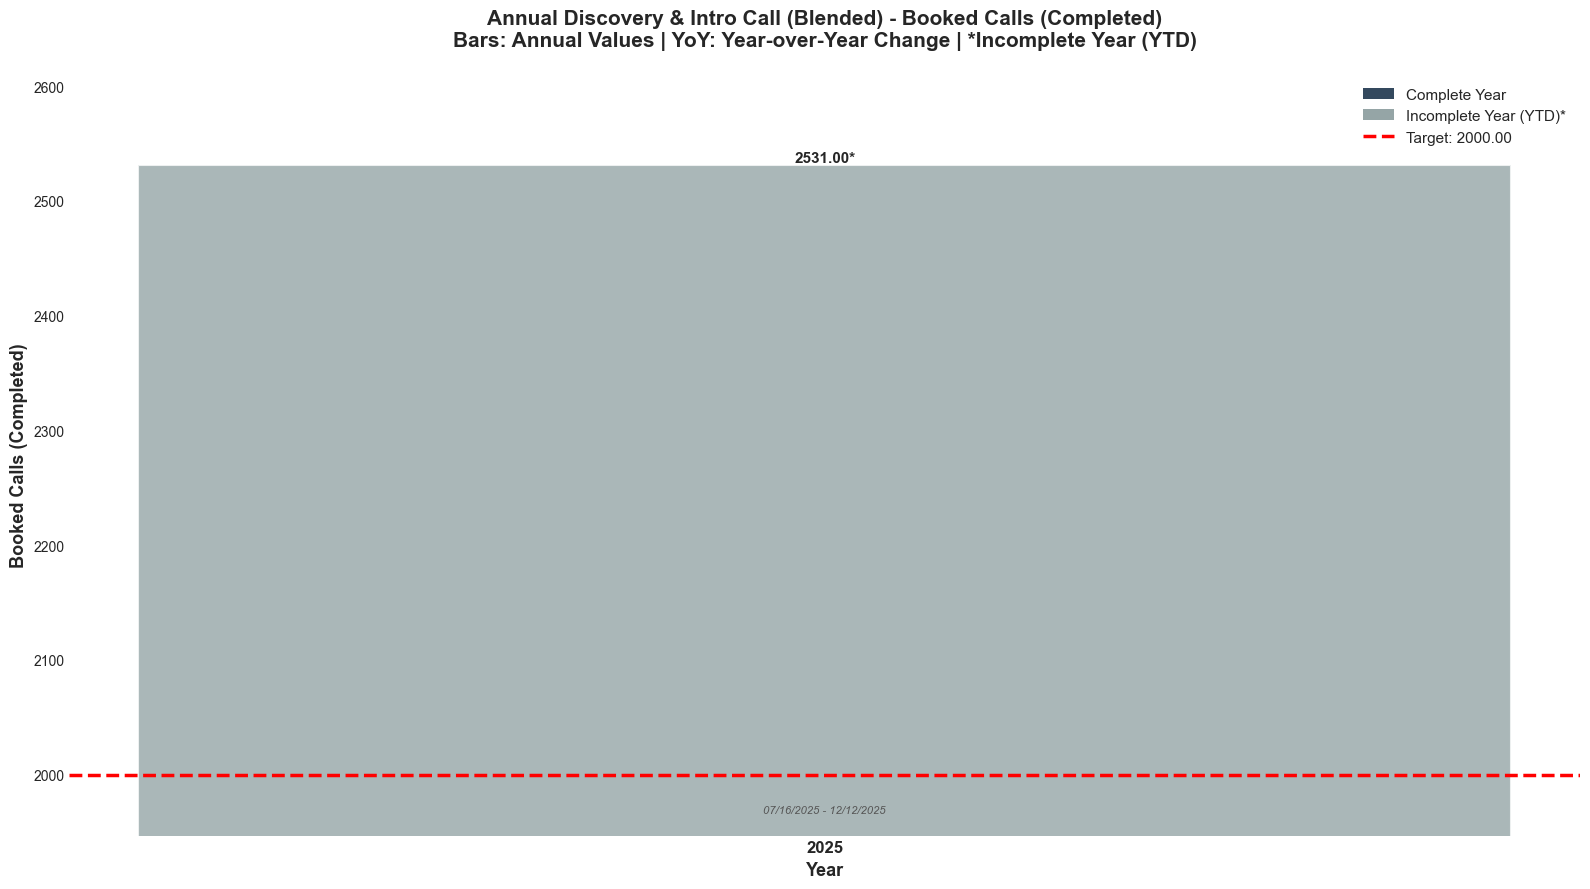

In [40]:
print("\n" + "=" * 70)
print("GENERATING DISCOVERY & INTRO CALL (BLENDED) - ANNUAL CHARTS")
print("=" * 70 + "\n")

# Annual Avg Lead Time (Completed)
create_annual_chart(
    csv_path='../outputs/discovery_intro/annual_discovery_intro_blended.csv',
    metric_col='Avg Lead Time (Days)(Completed)',
    target_value=annual_avg_lead_time_target,
    output_path=f'{viz_blended_annual_dir}/annual_avg_lead_time_completed.png',
    chart_title='Annual Discovery & Intro Call (Blended) - Avg Lead Time (Days)(Completed)',
    metric_name='Avg Lead Time (Days)(Completed)'
)

# Annual Booked Calls (Completed)
annual_blended_target = None
if annual_booked_discovery_target is not None and annual_booked_intro_target is not None:
    annual_blended_target = annual_booked_discovery_target + annual_booked_intro_target

create_annual_chart(
    csv_path='../outputs/discovery_intro/annual_discovery_intro_blended.csv',
    metric_col='Booked Calls (Completed)',
    target_value=annual_blended_target,
    output_path=f'{viz_blended_annual_dir}/annual_booked_calls_completed.png',
    chart_title='Annual Discovery & Intro Call (Blended) - Booked Calls (Completed)',
    metric_name='Booked Calls (Completed)'
)

#

### Visualization Summary

In [41]:
print("\n" + "=" * 70)
print("VISUALIZATION GENERATION COMPLETE")
print("=" * 70)

# Count generated files for Discovery Call
discovery_weekly_charts = len([f for f in os.listdir(viz_discovery_weekly_dir) if f.endswith('.png')])
discovery_monthly_charts = len([f for f in os.listdir(viz_discovery_monthly_dir) if f.endswith('.png')])
discovery_quarterly_charts = len([f for f in os.listdir(viz_discovery_quarterly_dir) if f.endswith('.png')])
discovery_annual_charts = len([f for f in os.listdir(viz_discovery_annual_dir) if f.endswith('.png')])
discovery_total = discovery_weekly_charts + discovery_monthly_charts + discovery_quarterly_charts + discovery_annual_charts

# Count generated files for Intro Call
intro_weekly_charts = len([f for f in os.listdir(viz_intro_weekly_dir) if f.endswith('.png')])
intro_monthly_charts = len([f for f in os.listdir(viz_intro_monthly_dir) if f.endswith('.png')])
intro_quarterly_charts = len([f for f in os.listdir(viz_intro_quarterly_dir) if f.endswith('.png')])
intro_annual_charts = len([f for f in os.listdir(viz_intro_annual_dir) if f.endswith('.png')])
intro_total = intro_weekly_charts + intro_monthly_charts + intro_quarterly_charts + intro_annual_charts

# Count generated files for Blended
blended_weekly_charts = len([f for f in os.listdir(viz_blended_weekly_dir) if f.endswith('.png')])
blended_monthly_charts = len([f for f in os.listdir(viz_blended_monthly_dir) if f.endswith('.png')])
blended_quarterly_charts = len([f for f in os.listdir(viz_blended_quarterly_dir) if f.endswith('.png')])
blended_annual_charts = len([f for f in os.listdir(viz_blended_annual_dir) if f.endswith('.png')])
blended_total = blended_weekly_charts + blended_monthly_charts + blended_quarterly_charts + blended_annual_charts

total_charts = discovery_total + intro_total + blended_total

print(f"\n📊 DISCOVERY CALL Charts Generated:")
print(f"  Weekly: {discovery_weekly_charts} (XmR Control Charts)")
print(f"  Monthly: {discovery_monthly_charts} (Trend + Target)")
print(f"  Quarterly: {discovery_quarterly_charts} (Bars + Trend + Target)")
print(f"  Annual: {discovery_annual_charts} (Bars + Trend + Target)")
print(f"  Subtotal: {discovery_total}")

print(f"\n📊 INTRO CALL Charts Generated:")
print(f"  Weekly: {intro_weekly_charts} (XmR Control Charts)")
print(f"  Monthly: {intro_monthly_charts} (Trend + Target)")
print(f"  Quarterly: {intro_quarterly_charts} (Bars + Trend + Target)")
print(f"  Annual: {intro_annual_charts} (Bars + Trend + Target)")
print(f"  Subtotal: {intro_total}")

print(f"\n📊 DISCOVERY & INTRO CALL (BLENDED) Charts Generated:")
print(f"  Weekly: {blended_weekly_charts} (XmR Control Charts)")
print(f"  Monthly: {blended_monthly_charts} (Trend + Target)")
print(f"  Quarterly: {blended_quarterly_charts} (Bars + Trend + Target)")
print(f"  Annual: {blended_annual_charts} (Bars + Trend + Target)")
print(f"  Subtotal: {blended_total}")

print(f"\n{'=' * 70}")
print(f"TOTAL CHARTS GENERATED: {total_charts}")
print(f"{'=' * 70}")

print("\n✓ All Discovery & Intro Call charts generated successfully!")
print("=" * 70 + "\n")


VISUALIZATION GENERATION COMPLETE

📊 DISCOVERY CALL Charts Generated:
  Weekly: 2 (XmR Control Charts)
  Monthly: 2 (Trend + Target)
  Quarterly: 2 (Bars + Trend + Target)
  Annual: 2 (Bars + Trend + Target)
  Subtotal: 8

📊 INTRO CALL Charts Generated:
  Weekly: 2 (XmR Control Charts)
  Monthly: 2 (Trend + Target)
  Quarterly: 2 (Bars + Trend + Target)
  Annual: 2 (Bars + Trend + Target)
  Subtotal: 8

📊 DISCOVERY & INTRO CALL (BLENDED) Charts Generated:
  Weekly: 2 (XmR Control Charts)
  Monthly: 2 (Trend + Target)
  Quarterly: 2 (Bars + Trend + Target)
  Annual: 2 (Bars + Trend + Target)
  Subtotal: 8

TOTAL CHARTS GENERATED: 24

✓ All Discovery & Intro Call charts generated successfully!



### List All Generated Charts

In [42]:
# Display all generated chart files
print("\n" + "=" * 70)
print("GENERATED CHART FILES - DISCOVERY CALL")
print("=" * 70 + "\n")

print("WEEKLY CHARTS (XmR Control Charts):")
print("-" * 70)
for file in sorted(os.listdir(viz_discovery_weekly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_discovery_weekly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nMONTHLY CHARTS (Trend + Target + MoM%):")
print("-" * 70)
for file in sorted(os.listdir(viz_discovery_monthly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_discovery_monthly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nQUARTERLY CHARTS (Bars + Trend + Target + QoQ%):")
print("-" * 70)
for file in sorted(os.listdir(viz_discovery_quarterly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_discovery_quarterly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nANNUAL CHARTS (Bars + Trend + Target + YoY%):")
print("-" * 70)
for file in sorted(os.listdir(viz_discovery_annual_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_discovery_annual_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\n" + "=" * 70)
print("GENERATED CHART FILES - INTRO CALL")
print("=" * 70 + "\n")

print("WEEKLY CHARTS (XmR Control Charts):")
print("-" * 70)
for file in sorted(os.listdir(viz_intro_weekly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_intro_weekly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nMONTHLY CHARTS (Trend + Target + MoM%):")
print("-" * 70)
for file in sorted(os.listdir(viz_intro_monthly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_intro_monthly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nQUARTERLY CHARTS (Bars + Trend + Target + QoQ%):")
print("-" * 70)
for file in sorted(os.listdir(viz_intro_quarterly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_intro_quarterly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nANNUAL CHARTS (Bars + Trend + Target + YoY%):")
print("-" * 70)
for file in sorted(os.listdir(viz_intro_annual_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_intro_annual_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\n" + "=" * 70)
print("GENERATED CHART FILES - DISCOVERY & INTRO CALL (BLENDED)")
print("=" * 70 + "\n")

print("WEEKLY CHARTS (XmR Control Charts):")
print("-" * 70)
for file in sorted(os.listdir(viz_blended_weekly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_blended_weekly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nMONTHLY CHARTS (Trend + Target + MoM%):")
print("-" * 70)
for file in sorted(os.listdir(viz_blended_monthly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_blended_monthly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nQUARTERLY CHARTS (Bars + Trend + Target + QoQ%):")
print("-" * 70)
for file in sorted(os.listdir(viz_blended_quarterly_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_blended_quarterly_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\nANNUAL CHARTS (Bars + Trend + Target + YoY%):")
print("-" * 70)
for file in sorted(os.listdir(viz_blended_annual_dir)):
    if file.endswith('.png'):
        file_path = os.path.join(viz_blended_annual_dir, file)
        file_size = os.path.getsize(file_path) / 1024
        print(f"  • {file:<50} ({file_size:.1f} KB)")

print("\n" + "=" * 70)


GENERATED CHART FILES - DISCOVERY CALL

WEEKLY CHARTS (XmR Control Charts):
----------------------------------------------------------------------
  • weekly_avg_lead_time_completed.png                 (485.2 KB)
  • weekly_booked_calls_completed.png                  (481.2 KB)

MONTHLY CHARTS (Trend + Target + MoM%):
----------------------------------------------------------------------
  • monthly_avg_lead_time_completed.png                (284.6 KB)
  • monthly_booked_calls_completed.png                 (252.1 KB)

QUARTERLY CHARTS (Bars + Trend + Target + QoQ%):
----------------------------------------------------------------------
  • quarterly_avg_lead_time_completed.png              (222.1 KB)
  • quarterly_booked_calls_completed.png               (213.1 KB)

ANNUAL CHARTS (Bars + Trend + Target + YoY%):
----------------------------------------------------------------------
  • annual_avg_lead_time_completed.png                 (207.2 KB)
  • annual_booked_calls_completed.png  

#

## CUSTOM DATE RANGE ANALYSIS

### Load Custom Date Range Parameters

In [43]:
# Load analysis reference dates from CSV
ref_dates_path = '../analysis_ref_date.csv'

# Check if file exists
if not os.path.exists(ref_dates_path):
    print(f"❌ Error: File not found at {ref_dates_path}")
    custom_start = None
    custom_end = None
else:
    # Load reference dates
    ref_dates = pd.read_csv(ref_dates_path, header=None)
    
    # Parse custom date range
    custom_start = None
    custom_end = None
    
    for idx, row in ref_dates.iterrows():
        if row[0] == 'Custom Start Date':
            try:
                custom_start = pd.to_datetime(row[1])
            except:
                custom_start = None
        elif row[0] == 'Custom End Date':
            try:
                custom_end = pd.to_datetime(row[1])
            except:
                custom_end = None
    
    print(f"Custom Date Range:")
    print(f"  Start: {custom_start if custom_start else 'Not specified'}")
    print(f"  End: {custom_end if custom_end else 'Not specified'}")
    
    if custom_start and custom_end:
        date_range_days = (custom_end - custom_start).days + 1
        print(f"  Duration: {date_range_days} days")
    else:
        print("\n⚠️ Custom date range not properly specified in analysis_ref_date.csv")

Custom Date Range:
  Start: 2025-11-01 00:00:00
  End: 2025-11-28 00:00:00
  Duration: 28 days


### Generate Custom Discovery Call Data

In [44]:
print("\n" + "="*70)
print("CUSTOM DATE RANGE - DISCOVERY CALL (WITH PREVIOUS PERIOD)")
print("="*70 + "\n")

if custom_start and custom_end:
    # Calculate previous period dates
    from dateutil.relativedelta import relativedelta
    prev_start = custom_start - relativedelta(months=1)
    prev_end = custom_end - relativedelta(months=1)
    
    date_range_duration = (custom_end - custom_start).days + 1
    print(f"Current Period: {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')} ({date_range_duration} days)")
    print(f"Previous Period: {prev_start.strftime('%m/%d/%Y')} - {prev_end.strftime('%m/%d/%Y')} ({date_range_duration} days)\n")
    
    df_custom_discovery_prep = df_discovery_daily.copy()
    df_custom_discovery_prep['Cancellation Rate'] = df_custom_discovery_prep['Cancellation Rate'].str.rstrip('%').astype(float)
    df_custom_discovery_prep['Date'] = pd.to_datetime(df_custom_discovery_prep['Date'])
    
    # Filter CURRENT period
    df_current = df_custom_discovery_prep[
        (df_custom_discovery_prep['Date'] >= custom_start) & 
        (df_custom_discovery_prep['Date'] <= custom_end)
    ].copy()
    
    # Filter PREVIOUS period
    df_prev = df_custom_discovery_prep[
        (df_custom_discovery_prep['Date'] >= prev_start) & 
        (df_custom_discovery_prep['Date'] <= prev_end)
    ].copy()
    
    discovery_rows = []
    
    # Process CURRENT period
    if len(df_current) > 0:
        actual_start = df_current['Date'].min()
        actual_end = df_current['Date'].max()
        
        discovery_rows.append({
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Event Type Name': 'Discovery Call',
            'Booked Calls (Completed)': int(df_current['Booked Calls (Completed)'].sum()),
            'Booked Calls (Canceled)': int(df_current['Booked Calls (Canceled)'].sum()),
            'Booked Calls': int(df_current['Booked Calls'].sum()),
            'Avg Lead Time (Days)(Completed)': round(df_current['Avg Lead Time (Days)(Completed)'].mean(), 2),
            'Avg Lead Time (Days)(Canceled)': round(df_current['Avg Lead Time (Days)(Canceled)'].mean(), 2),
            'Avg Lead Time (Days)': round(df_current['Avg Lead Time (Days)'].mean(), 2),
            'Cancellation Rate': f"{round(df_current['Cancellation Rate'].mean(), 2)}%"
        })
        print(f"✅ Current period: {len(df_current)} days, {df_current['Booked Calls'].sum()} total calls")
    else:
        print(f"⚠️ No current period data")
    
    # Process PREVIOUS period
    if len(df_prev) > 0:
        actual_start = df_prev['Date'].min()
        actual_end = df_prev['Date'].max()
        
        discovery_rows.append({
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Event Type Name': 'Discovery Call',
            'Booked Calls (Completed)': int(df_prev['Booked Calls (Completed)'].sum()),
            'Booked Calls (Canceled)': int(df_prev['Booked Calls (Canceled)'].sum()),
            'Booked Calls': int(df_prev['Booked Calls'].sum()),
            'Avg Lead Time (Days)(Completed)': round(df_prev['Avg Lead Time (Days)(Completed)'].mean(), 2),
            'Avg Lead Time (Days)(Canceled)': round(df_prev['Avg Lead Time (Days)(Canceled)'].mean(), 2),
            'Avg Lead Time (Days)': round(df_prev['Avg Lead Time (Days)'].mean(), 2),
            'Cancellation Rate': f"{round(df_prev['Cancellation Rate'].mean(), 2)}%"
        })
        print(f"✅ Previous period: {len(df_prev)} days, {df_prev['Booked Calls'].sum()} total calls")
    else:
        print(f"⚠️ No previous period data")
    
    if len(discovery_rows) > 0:
        df_custom_discovery = pd.DataFrame(discovery_rows)
        print("\nCustom Discovery Call Data (with Previous Period):")
        display(df_custom_discovery)
    else:
        df_custom_discovery = None
else:
    df_custom_discovery = None

print("\n" + "="*70)


CUSTOM DATE RANGE - DISCOVERY CALL (WITH PREVIOUS PERIOD)

Current Period: 11/01/2025 - 11/28/2025 (28 days)
Previous Period: 10/01/2025 - 10/28/2025 (28 days)

✅ Current period: 28 days, 499 total calls
✅ Previous period: 28 days, 379 total calls

Custom Discovery Call Data (with Previous Period):


,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,11/01/2025 - 11/28/2025,Discovery Call,403,96,499,3.94,4.11,3.95,19.88%
1,10/01/2025 - 10/28/2025,Discovery Call,315,64,379,2.57,3.07,2.69,18.07%


### Generate Custom Intro Call Data

In [45]:
print("\n" + "="*70)
print("CUSTOM DATE RANGE - INTRO CALL (WITH PREVIOUS PERIOD)")
print("="*70 + "\n")

if custom_start and custom_end:
    df_custom_intro_prep = df_intro_daily.copy()
    df_custom_intro_prep['Cancellation Rate'] = df_custom_intro_prep['Cancellation Rate'].str.rstrip('%').astype(float)
    df_custom_intro_prep['Date'] = pd.to_datetime(df_custom_intro_prep['Date'])
    
    # Filter CURRENT period
    df_current = df_custom_intro_prep[
        (df_custom_intro_prep['Date'] >= custom_start) & 
        (df_custom_intro_prep['Date'] <= custom_end)
    ].copy()
    
    # Filter PREVIOUS period
    df_prev = df_custom_intro_prep[
        (df_custom_intro_prep['Date'] >= prev_start) & 
        (df_custom_intro_prep['Date'] <= prev_end)
    ].copy()
    
    intro_rows = []
    
    # Process CURRENT period
    if len(df_current) > 0:
        actual_start = df_current['Date'].min()
        actual_end = df_current['Date'].max()
        
        intro_rows.append({
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Event Type Name': 'Intro Call',
            'Booked Calls (Completed)': int(df_current['Booked Calls (Completed)'].sum()),
            'Booked Calls (Canceled)': int(df_current['Booked Calls (Canceled)'].sum()),
            'Booked Calls': int(df_current['Booked Calls'].sum()),
            'Avg Lead Time (Days)(Completed)': round(df_current['Avg Lead Time (Days)(Completed)'].mean(), 2),
            'Avg Lead Time (Days)(Canceled)': round(df_current['Avg Lead Time (Days)(Canceled)'].mean(), 2),
            'Avg Lead Time (Days)': round(df_current['Avg Lead Time (Days)'].mean(), 2),
            'Cancellation Rate': f"{round(df_current['Cancellation Rate'].mean(), 2)}%"
        })
        print(f"✅ Current period: {len(df_current)} days, {df_current['Booked Calls'].sum()} total calls")
    else:
        print(f"⚠️ No current period data")
    
    # Process PREVIOUS period
    if len(df_prev) > 0:
        actual_start = df_prev['Date'].min()
        actual_end = df_prev['Date'].max()
        
        intro_rows.append({
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Event Type Name': 'Intro Call',
            'Booked Calls (Completed)': int(df_prev['Booked Calls (Completed)'].sum()),
            'Booked Calls (Canceled)': int(df_prev['Booked Calls (Canceled)'].sum()),
            'Booked Calls': int(df_prev['Booked Calls'].sum()),
            'Avg Lead Time (Days)(Completed)': round(df_prev['Avg Lead Time (Days)(Completed)'].mean(), 2),
            'Avg Lead Time (Days)(Canceled)': round(df_prev['Avg Lead Time (Days)(Canceled)'].mean(), 2),
            'Avg Lead Time (Days)': round(df_prev['Avg Lead Time (Days)'].mean(), 2),
            'Cancellation Rate': f"{round(df_prev['Cancellation Rate'].mean(), 2)}%"
        })
        print(f"✅ Previous period: {len(df_prev)} days, {df_prev['Booked Calls'].sum()} total calls")
    else:
        print(f"⚠️ No previous period data")
    
    if len(intro_rows) > 0:
        df_custom_intro = pd.DataFrame(intro_rows)
        print("\nCustom Intro Call Data (with Previous Period):")
        display(df_custom_intro)
    else:
        df_custom_intro = None
else:
    df_custom_intro = None

print("\n" + "="*70)


CUSTOM DATE RANGE - INTRO CALL (WITH PREVIOUS PERIOD)

✅ Current period: 28 days, 160 total calls
✅ Previous period: 27 days, 98 total calls

Custom Intro Call Data (with Previous Period):


,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,11/01/2025 - 11/28/2025,Intro Call,144,16,160,3.24,4.05,3.28,11.82%
1,10/01/2025 - 10/28/2025,Intro Call,89,9,98,2.25,1.87,2.21,8.77%


### Generate Custom Blended Data (Discovery & Intro Combined)

In [46]:
print("\n" + "="*70)
print("CUSTOM DATE RANGE - DISCOVERY & INTRO CALL BLENDED (WITH PREVIOUS PERIOD)")
print("="*70 + "\n")

if custom_start and custom_end:
    df_custom_blended_prep = df_blended_daily.copy()
    df_custom_blended_prep['Cancellation Rate'] = df_custom_blended_prep['Cancellation Rate'].str.rstrip('%').astype(float)
    df_custom_blended_prep['Date'] = pd.to_datetime(df_custom_blended_prep['Date'])
    
    # Filter CURRENT period
    df_current = df_custom_blended_prep[
        (df_custom_blended_prep['Date'] >= custom_start) & 
        (df_custom_blended_prep['Date'] <= custom_end)
    ].copy()
    
    # Filter PREVIOUS period
    df_prev = df_custom_blended_prep[
        (df_custom_blended_prep['Date'] >= prev_start) & 
        (df_custom_blended_prep['Date'] <= prev_end)
    ].copy()
    
    blended_rows = []
    
    # Process CURRENT period
    if len(df_current) > 0:
        actual_start = df_current['Date'].min()
        actual_end = df_current['Date'].max()
        
        blended_rows.append({
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Event Type Name': 'Discovery & Intro Call',
            'Booked Calls (Completed)': int(df_current['Booked Calls (Completed)'].sum()),
            'Booked Calls (Canceled)': int(df_current['Booked Calls (Canceled)'].sum()),
            'Booked Calls': int(df_current['Booked Calls'].sum()),
            'Avg Lead Time (Days)(Completed)': round(df_current['Avg Lead Time (Days)(Completed)'].mean(), 2),
            'Avg Lead Time (Days)(Canceled)': round(df_current['Avg Lead Time (Days)(Canceled)'].mean(), 2),
            'Avg Lead Time (Days)': round(df_current['Avg Lead Time (Days)'].mean(), 2),
            'Cancellation Rate': f"{round(df_current['Cancellation Rate'].mean(), 2)}%"
        })
        print(f"✅ Current period: {len(df_current)} days, {df_current['Booked Calls'].sum()} total calls")
    else:
        print(f"⚠️ No current period data")
    
    # Process PREVIOUS period
    if len(df_prev) > 0:
        actual_start = df_prev['Date'].min()
        actual_end = df_prev['Date'].max()
        
        blended_rows.append({
            'Date Range': f"{actual_start.strftime('%m/%d/%Y')} - {actual_end.strftime('%m/%d/%Y')}",
            'Event Type Name': 'Discovery & Intro Call',
            'Booked Calls (Completed)': int(df_prev['Booked Calls (Completed)'].sum()),
            'Booked Calls (Canceled)': int(df_prev['Booked Calls (Canceled)'].sum()),
            'Booked Calls': int(df_prev['Booked Calls'].sum()),
            'Avg Lead Time (Days)(Completed)': round(df_prev['Avg Lead Time (Days)(Completed)'].mean(), 2),
            'Avg Lead Time (Days)(Canceled)': round(df_prev['Avg Lead Time (Days)(Canceled)'].mean(), 2),
            'Avg Lead Time (Days)': round(df_prev['Avg Lead Time (Days)'].mean(), 2),
            'Cancellation Rate': f"{round(df_prev['Cancellation Rate'].mean(), 2)}%"
        })
        print(f"✅ Previous period: {len(df_prev)} days, {df_prev['Booked Calls'].sum()} total calls")
    else:
        print(f"⚠️ No previous period data")
    
    if len(blended_rows) > 0:
        df_custom_blended = pd.DataFrame(blended_rows)
        print("\nCustom Blended Data (with Previous Period):")
        display(df_custom_blended)
    else:
        df_custom_blended = None
else:
    df_custom_blended = None

print("\n" + "="*70)


CUSTOM DATE RANGE - DISCOVERY & INTRO CALL BLENDED (WITH PREVIOUS PERIOD)

✅ Current period: 28 days, 659 total calls
✅ Previous period: 28 days, 477 total calls

Custom Blended Data (with Previous Period):


,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,11/01/2025 - 11/28/2025,Discovery & Intro Call,547,112,659,3.80,4.04,3.85,17.14%
1,10/01/2025 - 10/28/2025,Discovery & Intro Call,404,73,477,2.53,2.93,2.59,16.47%


### Save All Custom Date Range Data

In [47]:
print("\n" + "="*70)
print("SAVING CUSTOM DATE RANGE FILES")
print("="*70 + "\n")

files_saved = []

# Save Discovery Call
if df_custom_discovery is not None and len(df_custom_discovery) > 0:
    discovery_path = os.path.join(output_dir, 'custom_discovery_call.csv')
    df_custom_discovery.to_csv(discovery_path, index=False)
    files_saved.append('custom_discovery_call.csv')
    print(f"✅ Saved: {discovery_path}")

# Save Intro Call
if df_custom_intro is not None and len(df_custom_intro) > 0:
    intro_path = os.path.join(output_dir, 'custom_intro_call.csv')
    df_custom_intro.to_csv(intro_path, index=False)
    files_saved.append('custom_intro_call.csv')
    print(f"✅ Saved: {intro_path}")

# Save Blended (Discovery & Intro)
if df_custom_blended is not None and len(df_custom_blended) > 0:
    blended_path = os.path.join(output_dir, 'custom_discovery_intro_blended.csv')
    df_custom_blended.to_csv(blended_path, index=False)
    files_saved.append('custom_discovery_intro_blended.csv')
    print(f"✅ Saved: {blended_path}")

if len(files_saved) > 0:
    print("\n" + "="*70)
    print("CUSTOM DATE RANGE ANALYSIS - COMPLETE")
    print("="*70)
    
    print(f"\n✅ FILES CREATED ({len(files_saved)}):")
    for file in files_saved:
        print(f"  - {file}")
    
    print(f"\n📁 Saved in:")
    print(f"  - ../outputs/discovery_intro/")
    
    if custom_start and custom_end:
        print(f"\n📊 Date Range:")
        print(f"  - {custom_start.strftime('%m/%d/%Y')} - {custom_end.strftime('%m/%d/%Y')}")
        print(f"  - Duration: {(custom_end - custom_start).days + 1} days")
    
    print("\n" + "="*70)
else:
    print("\n⚠️ No custom files saved - no data available")
    print("   Check date range and data availability")


SAVING CUSTOM DATE RANGE FILES

✅ Saved: ../outputs/discovery_intro/custom_discovery_call.csv
✅ Saved: ../outputs/discovery_intro/custom_intro_call.csv
✅ Saved: ../outputs/discovery_intro/custom_discovery_intro_blended.csv

CUSTOM DATE RANGE ANALYSIS - COMPLETE

✅ FILES CREATED (3):
  - custom_discovery_call.csv
  - custom_intro_call.csv
  - custom_discovery_intro_blended.csv

📁 Saved in:
  - ../outputs/discovery_intro/

📊 Date Range:
  - 11/01/2025 - 11/28/2025
  - Duration: 28 days



### Verification - Preview All Custom Files

In [48]:
print("\n" + "="*70)
print("CUSTOM DATE RANGE DATA PREVIEW")
print("="*70)

if df_custom_discovery is not None and len(df_custom_discovery) > 0:
    print("\n1️⃣ DISCOVERY CALL:")
    print("-" * 70)
    display(df_custom_discovery)

if df_custom_intro is not None and len(df_custom_intro) > 0:
    print("\n2️⃣ INTRO CALL:")
    print("-" * 70)
    display(df_custom_intro)

if df_custom_blended is not None and len(df_custom_blended) > 0:
    print("\n3️⃣ BLENDED (DISCOVERY & INTRO):")
    print("-" * 70)
    display(df_custom_blended)

if all([
    df_custom_discovery is not None and len(df_custom_discovery) > 0,
    df_custom_intro is not None and len(df_custom_intro) > 0,
    df_custom_blended is not None and len(df_custom_blended) > 0
]):
    print("\n" + "="*70)
    print("✓ All custom date range analyses completed successfully!")
    print("="*70)
else:
    print("\n⚠️ Some analyses could not be completed")
    print("   Check if data exists for all call types in the specified date range")


CUSTOM DATE RANGE DATA PREVIEW

1️⃣ DISCOVERY CALL:
----------------------------------------------------------------------


,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,11/01/2025 - 11/28/2025,Discovery Call,403,96,499,3.94,4.11,3.95,19.88%
1,10/01/2025 - 10/28/2025,Discovery Call,315,64,379,2.57,3.07,2.69,18.07%



2️⃣ INTRO CALL:
----------------------------------------------------------------------


,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,11/01/2025 - 11/28/2025,Intro Call,144,16,160,3.24,4.05,3.28,11.82%
1,10/01/2025 - 10/28/2025,Intro Call,89,9,98,2.25,1.87,2.21,8.77%



3️⃣ BLENDED (DISCOVERY & INTRO):
----------------------------------------------------------------------


,Date Range,Event Type Name,Booked Calls (Completed),Booked Calls (Canceled),Booked Calls,Avg Lead Time (Days)(Completed),Avg Lead Time (Days)(Canceled),Avg Lead Time (Days),Cancellation Rate
0,11/01/2025 - 11/28/2025,Discovery & Intro Call,547,112,659,3.80,4.04,3.85,17.14%
1,10/01/2025 - 10/28/2025,Discovery & Intro Call,404,73,477,2.53,2.93,2.59,16.47%



✓ All custom date range analyses completed successfully!
